In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

import utils.utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [ ]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6A/pileup.genomic.npz"
with np.load(hela_df, allow_pickle=True) as data:
    hela_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_df = hela_df[hela_df["count_dom"] >= 20]
print(hela_df)

In [ ]:
hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.genomic.npz"
with np.load(hek_df, allow_pickle=True) as data:
    hek_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_df = hek_df[hek_df["count_dom"] >= 20]
print(hek_df)

In [ ]:
threshold = 0.712

def calc_pm6a(df):
    return -(2-df["dom"])*df["logsum_1_p_pos"]/df["count_all"] + ((1-df["dom"])*np.log10(np.clip(1-df["dom"],1e-30,1)) + df["dom"] * np.log10(np.clip(df["dom"],1e-30,1)))*(df["count_pos"]/df["count_all"])

hela_df["pm6a"] = calc_pm6a(hela_df)
hek_df["pm6a"] = calc_pm6a(hek_df)

hela_df_m6a = hela_df[hela_df["pm6a"] > threshold].copy()
hek_df_m6a = hek_df[hek_df["pm6a"] > threshold].copy()

In [ ]:
print(hela_df_m6a)
print(hek_df_m6a)

In [ ]:
hek_label = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/v2Genomic.GP3.depth5_None.twm6astrict.pkl")

In [ ]:
print(hek_label)

In [ ]:
hek_eval = hek_df_m6a.merge(hek_label, on="genome_id", how="left")

In [ ]:
print(hek_eval)

In [ ]:
print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}))

In [656]:
## Count DRACH+Coding, DRACH+Noncoding, Non-DRACH+Coding, Non-DRACH+Noncoding
print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/hek_eval["genome_id"].nunique())

print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size())
print(sum(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))

coding  drach
False   False    0.006286
        True     0.048947
True    False    0.084536
        True     0.860231
dtype: float64
coding  drach
False   False      664
        True      5170
True    False     8929
        True     90861
dtype: int64
105624


[90861, 5170, 664, 8929]


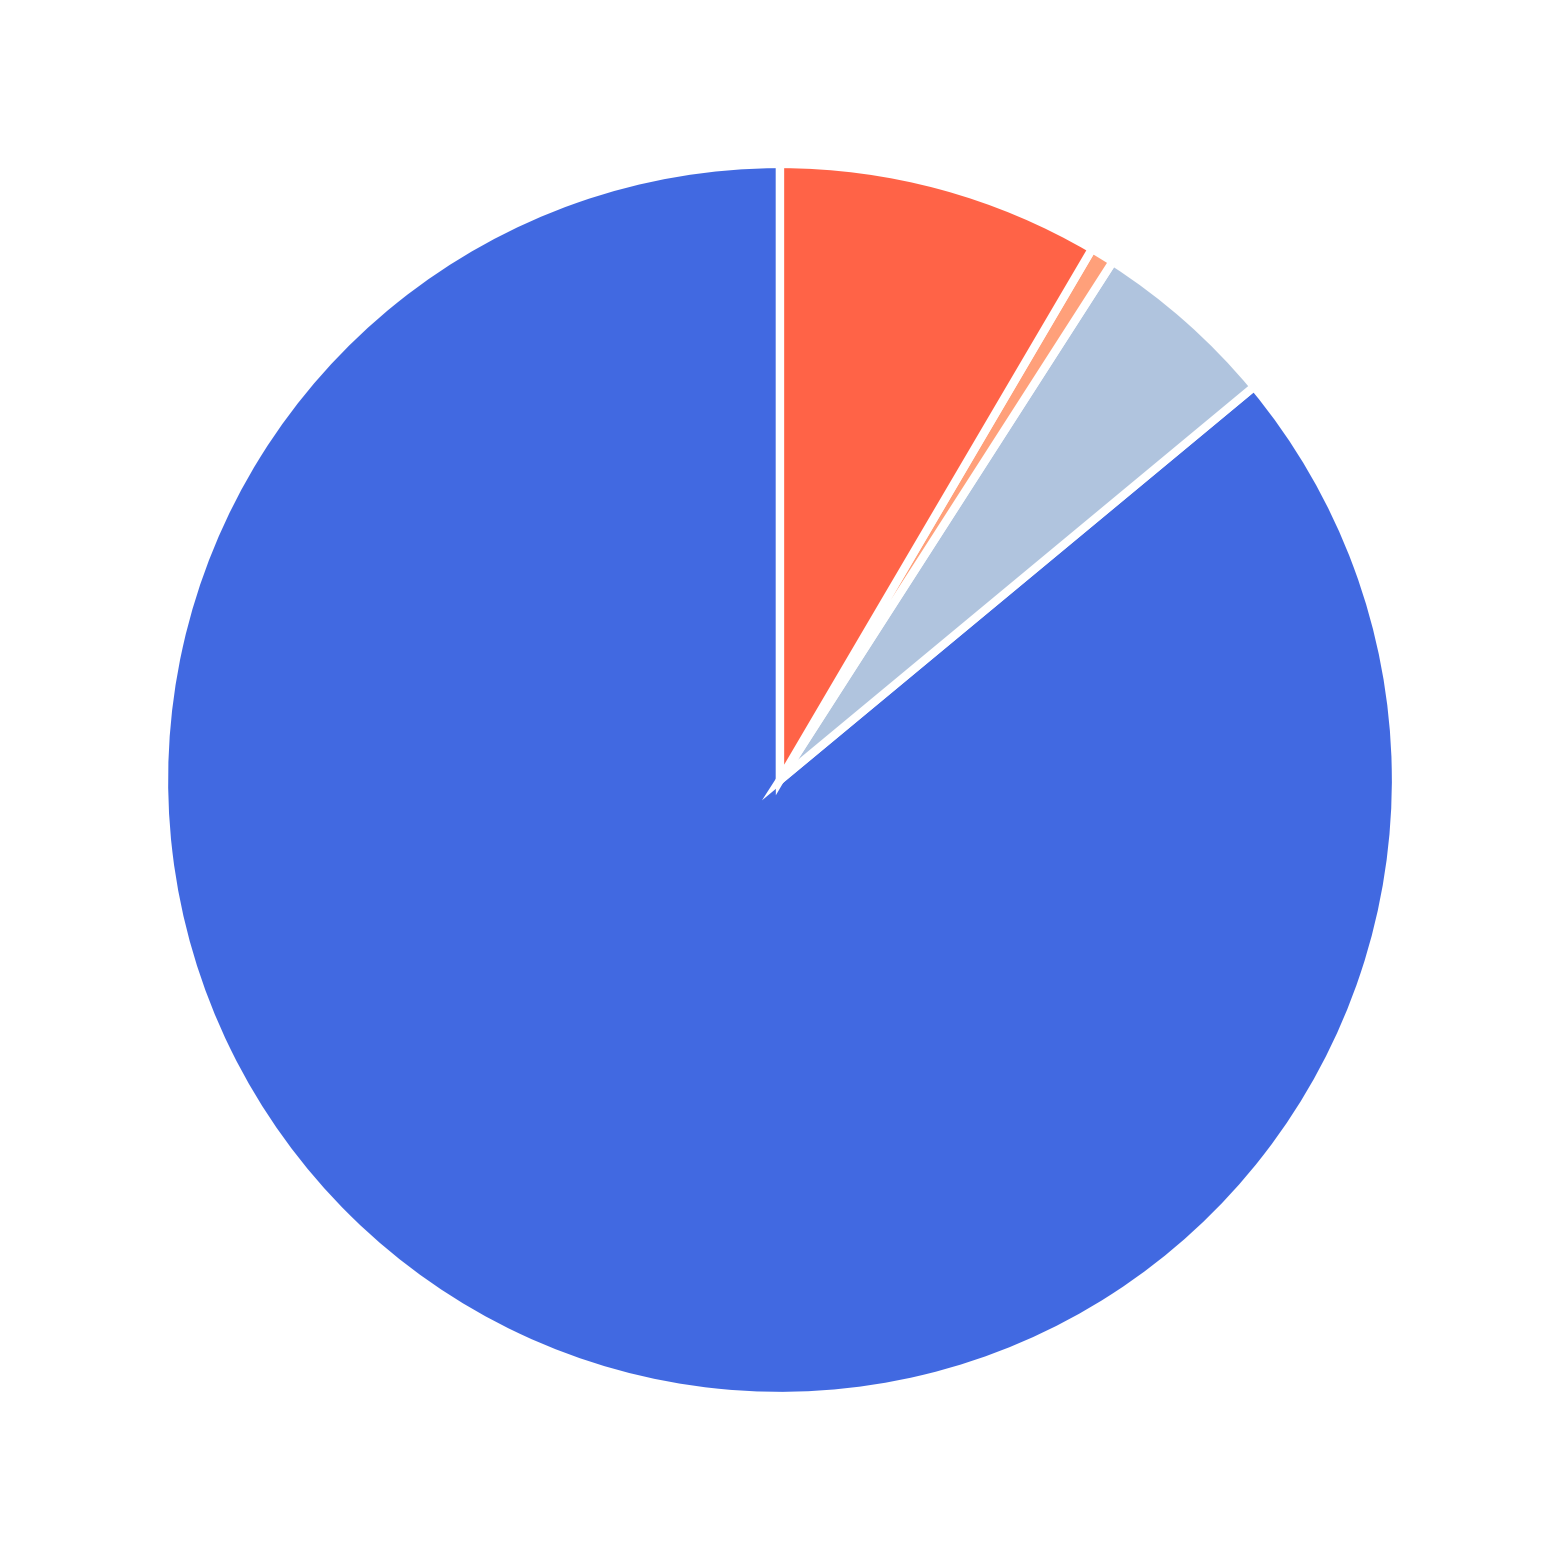

In [654]:
## Plot Pie chart
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [90861, 5170, 664, 8929]
print(y)
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon',  'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie.pdf", format="pdf")
plt.show()

In [ ]:
hela_arr = hela_df_m6a.groupby("gene_symbol").size()
hek_arr = hek_df_m6a.groupby("gene_symbol").size()

In [ ]:
## Add genes with 0 m6A sites
hela_arr = hela_arr.reindex(hela_df["gene_symbol"].unique(), fill_value=0)
hek_arr = hek_arr.reindex(hek_df["gene_symbol"].unique(), fill_value=0)


In [ ]:
## Plot histogram
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(np.clip(hela_arr, 0, 60), color="tomato", label="HeLa", element="step", ax=ax, fill=False, binwidth=2, stat="density")
sns.histplot(np.clip(hek_arr, 0, 60), color="royalblue", label="HEK293T", element="step", ax=ax, fill=False, binwidth=2, stat="density")
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/density.pdf", format="pdf")
plt.show()

In [ ]:
## How many genes have> 30 m6A sites?
print(len(hela_arr[hela_arr > 30]))
print(len(hek_arr[hek_arr > 30]))

In [ ]:
## How many genes have m6A sites?
print(len(hela_arr[hela_arr > 0])/hela_df["gene_symbol"].nunique())
print(len(hek_arr[hek_arr > 0])/hek_df["gene_symbol"].nunique())

In [ ]:
## Average number of m6A sites per gene
print(hela_arr.mean())
print(hek_arr.mean())



In [ ]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
hela_arr = hela_arr.sort_values(ascending=False)
hek_arr = hek_arr.sort_values(ascending=False)
## Vertical bar plot
sns.barplot(x=hela_arr[:10], y=hela_arr[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_arr[:10], y=hek_arr[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [ ]:
##print top10 genes

print("\n".join(hela_arr[:10].index))
print("")
print("\n".join(hek_arr[:10].index))

In [ ]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6A/pileup.npz"
with np.load(hela_df, allow_pickle=True) as data:
    hela_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_df = hela_df[hela_df["count_dom"] >= 20]
print(hela_df)

In [629]:
hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(hek_df, allow_pickle=True) as data:
    hek_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_df = hek_df[hek_df["count_dom"] >= 20]
print(hek_df)

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000   0.606511      0.000000        0.000000          0   
1         NM_000016:1008   0.948786      0.000000        0.000000          0   
2         NM_000016:1009   2.607620      0.000000        0.000000          0   
3         NM_000016:1010   4.912612      0.000000        0.000000          0   
4         NM_000016:1014   3.237954      0.000000        0.000000          0   
...                  ...        ...           ...             ...        ...   
30894417    NR_184306:85   1.133184      0.000000        0.000000          0   
30894420    NR_184306:87   3.771550     -0.001452       -2.476578          1   
30894423    NR_184306:88   2.137289      0.000000        0.000000          0   
30894435    NR_184306:93  32.341377     -0.011076      -78.301079         23   
30894446    NR_184306:98   4.046034      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg 

In [630]:
hela_df["pm6a"] = calc_pm6a(hela_df)
hek_df["pm6a"] = calc_pm6a(hek_df)
hela_df["refseq"] = hela_df["label_id"].str.split(":", expand=True)[0]
hek_df["refseq"] = hek_df["label_id"].str.split(":", expand=True)[0]
hela_df["pos"] = hela_df["label_id"].str.split(":", expand=True)[1].astype(int)
hek_df["pos"] = hek_df["label_id"].str.split(":", expand=True)[1].astype(int)

In [ ]:
hela_df_m6a = hela_df[hela_df["pm6a"] > threshold].copy()
hek_df_m6a = hek_df[hek_df["pm6a"] > threshold].copy()

In [ ]:
## get m6a pos for each refseq

hela_dict = hela_df_m6a.groupby("refseq").apply(lambda x: x["pos"].values)
hek_dict = hek_df_m6a.groupby("refseq").apply(lambda x: x["pos"].values)

In [ ]:
print(hela_dict)

In [ ]:
## Get genes for largest discrepancy

gene_dict = []
for refseq in hela_dict.index:
    if refseq in hek_dict:
        hela_pos = hela_dict[refseq]
        hek_pos = hek_dict[refseq]
        diff = np.setdiff1d(hela_pos, hek_pos)
        if len(diff) > 0:
            gene_dict.append((refseq, len(diff)))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "diff"])

In [ ]:
print(diff_df)

In [ ]:
print(diff_df.sort_values("diff", ascending=False))

In [ ]:

hela_df["refseq"] = hela_df["label_id"].str.split(":").str[0]
hek_df["refseq"] = hek_df["label_id"].str.split(":").str[0]
hela_df["pos"] = hela_df["label_id"].str.split(":").str[1].astype(int)
hek_df["pos"] = hek_df["label_id"].str.split(":").str[1].astype(int)

In [ ]:
print(hela_df[hela_df["refseq"] == "NM_022489"]["count_dom"].describe())
print(hek_df[hek_df["refseq"] == "NM_022489"]["count_dom"].describe())

In [ ]:
from Bio import SeqIO
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}

In [ ]:
a_count_dict = {x: y.seq.count("A") for x, y in fasta_dict.items()}

In [ ]:
hek_count_df = hek_df["refseq"].value_counts()
hela_count_df = hela_df["refseq"].value_counts()
hek_start_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].min())
hela_start_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].min())


In [402]:
hek_end_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].max())
hela_end_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].max())

In [422]:
gene_list = []
for gene_id in tqdm.tqdm(a_count_dict):
    a_count = a_count_dict[gene_id]
    hek_count = hek_count_df.get(gene_id, 0)
    hela_count = hela_count_df.get(gene_id, 0)
    if hek_count >= a_count * 0.75 and hela_count >= a_count * 0.75:
        if np.abs(hela_count - hek_count) < 10:
            if np.abs(hek_start_df.get(gene_id, 0) - hela_start_df.get(gene_id, 0)) < 100:
                if np.abs(hek_end_df.get(gene_id, 0) - hela_end_df.get(gene_id, 0)) < 100:
                    gene_list.append(gene_id)

print(len(gene_list))
        

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87410/87410 [00:01<00:00, 70440.94it/s]

8380


In [560]:
gene_list = [x for x in a_count_dict if x in hela_dict or x in hek_dict]
print(len(gene_list))

23106


In [486]:
## Draw Discrepancy
gene_len_dict = {x: len(fasta_dict[x]) for x in gene_list}
geneid_table = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/res/ref/GRCh38_latest_genomic.convert_table.pkl")
convert_dict = dict(zip(geneid_table["transcript_id"], geneid_table["gene_id"]))

In [ ]:
## Get genes for largest discrepancy

hela_df_m6a_groupby = hela_df_m6a.groupby("refseq")
hek_df_m6a_groupby = hek_df_m6a.groupby("refseq")


In [ ]:
## Get

In [499]:
hela_df_ca = hela_df[hela_df["pm6a"] < threshold].copy()
hek_df_ca = hek_df[hek_df["pm6a"] < threshold].copy()

print(len(hela_df_ca)/len(hela_df))
print(len(hek_df_ca)/len(hek_df))

0.990332269181182
0.990515019194194


In [551]:

def plot(refseq):    
    hela_refseq_df = hela_df_m6a[hela_df_m6a["refseq"] == refseq]
    hela_pos = hela_refseq_df["pos"].values
    hela_dom = hela_refseq_df["dom"].values
    hek_refseq_df = hek_df_m6a[hek_df_m6a["refseq"] == refseq]
    hek_pos = hek_refseq_df["pos"].values
    hek_dom = hek_refseq_df["dom"].values

    hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])

    hela_pos_bool = np.isin(hela_pos, hek_all_pos)
    hek_pos_bool = np.isin(hek_pos, hela_all_pos)
    
    hela_pos = hela_pos[hela_pos_bool]
    hek_pos = hek_pos[hek_pos_bool]
    hela_dom = hela_dom[hela_pos_bool]
    hek_dom = hek_dom[hek_pos_bool]
    
    print(refseq)
    
    max_pos = gene_len_dict[refseq]
    
    x_min = 0
    x_max = max_pos//100 * 100 + 100
    
    if x_max - x_min > 4000:
        x_grid = 400
    
    elif x_max - x_min > 2000:
        x_grid = 200
    
    else:
        x_grid = 100
    
    fig, ax = plt.subplots(figsize=(20,10))
    
    ax.set_xticks(range(x_min, x_max, x_grid))
    ax.set_xticklabels([str(x) for x in range(x_min, x_max, x_grid)])
    ax.set_xlim(x_min - 10, x_max + 10)
    ax.set_ylim(-1, 1)
    ax.set_yticks(list(np.arange(-1,1.1,0.25)))
    ax.set_yticklabels([f"{x:.2f}" for x in np.arange(-1,1.1,0.25)])
    ax.grid()
    
    barwidth = 0.01 * (x_max - x_min + 20)
    
    ax.bar(hek_pos, hek_dom, label="HEK293T", color="royalblue", width=barwidth)
    ax.bar(hela_pos, -hela_dom, label="HeLa", color="tomato", width=barwidth)
    

    gene_symbol = convert_dict[refseq]

    ax.set_title(f"{gene_symbol}({refseq}) m6A Profile")
    ax.set_xlabel("Position (nt)")
    ax.set_ylabel("Degree of Modification")
    ax.legend() 
    
    ## hline at y=0
    ax.axhline(0, color="black", lw=3)
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/{refseq}.pdf", format="pdf")

    plt.show()


In [501]:
hela_df_ca_groupby = hela_df_ca.groupby("refseq")
hek_df_ca_groupby = hek_df_ca.groupby("refseq")

In [664]:

gene_dict = []
for refseq in tqdm.tqdm(gene_list):
    try:
        hela_pos = hela_dict[refseq]
        hela_dom = hela_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hela_pos = []
        hela_dom = []
    try:
        hek_pos = hek_dict[refseq]
        hek_dom = hek_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hek_pos = []
        hek_dom = []
        
    try:
        hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hela_ca_pos = []
    try:
        hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hek_ca_pos = []
    
    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])
    
    

    hela_dom_dict = dict(zip(hela_pos, hela_dom))
    hek_dom_dict = dict(zip(hek_pos, hek_dom))

    unique = 0
    
    hela_valid_pos = []
    hek_valid_pos = []
    
    hela_arr = []
    hek_arr = []
    
    for pos in np.union1d(hela_pos, hek_pos):
        if pos in hela_all_pos and pos in hek_all_pos:
            if pos in hela_pos:
                hela_valid_pos.append(pos)
            if pos in hek_pos:
                hek_valid_pos.append(pos)
            hela_dom = hela_dom_dict.get(pos, 0)
            hek_dom = hek_dom_dict.get(pos, 0)
            hela_arr.append(hela_dom)
            hek_arr.append(hek_dom)
            if hela_dom*hek_dom == 0:
                if np.abs(hela_dom-hek_dom) > 0.5:
                    unique += 1
                    
    if len(hela_arr) > 0 or len(hek_arr) > 0:
        
        hela_arr = np.array(hela_arr)
        hek_arr = np.array(hek_arr)
        hela_valid_pos = np.array(hela_valid_pos)
        hek_valid_pos = np.array(hek_valid_pos)
    
        i = np.intersect1d(hela_valid_pos, hek_valid_pos)
        u = np.union1d(hela_valid_pos, hek_valid_pos)
        
        cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
        if np.isnan(cosine_sim):
            cosine_sim = 0
        cross_entropy = -np.sum(hela_arr*np.log(hek_arr+1e-30) + (1-hela_arr)*np.log(1-hek_arr+1e-30))/len(hela_arr)
        iou = len(i)/len(u)
        
        hela_size = len(hela_valid_pos)
        hek_size = len(hek_valid_pos)
        
        l1 = np.mean(np.abs(hela_arr-hek_arr))
        l2 = np.mean((hela_arr-hek_arr)**2)/np.sum(hela_arr-hek_arr)
        
        gene_dict.append((refseq, cosine_sim, cross_entropy, hela_size, hek_size, iou, unique, l1, l2))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "cosine_sim", "cross_entropy", "hela_size", "hek_size", "iou", "unique", "l1", "l2"])

print(diff_df)

  0%|                                                                                                                                                                    | 0/23106 [00:00<?, ?it/s]/tmp/ipykernel_258987/3755516363.py:65: RuntimeWarning: invalid value encountered in scalar divide
  cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
  7%|██████████▊                                                                                                                                             | 1651/23106 [00:02<00:31, 684.89it/s]/tmp/ipykernel_258987/3755516363.py:75: RuntimeWarning: invalid value encountered in scalar divide
  l2 = np.mean((hela_arr-hek_arr)**2)/np.sum(hela_arr-hek_arr)
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23106/23106 [00:29<00:00, 791.38it/s]

          refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
0      NM_000016    1.000000       0.580291          1         1  1.000000   
1      NM_000017    0.976950       0.486861          2         3  0.666667   
2      NM_000021    0.986966       2.591599         20        16  0.800000   
3      NM_000027    1.000000       0.601162          1         1  1.000000   
4      NM_000028    1.000000       0.609066          1         1  1.000000   
...          ...         ...            ...        ...       ...       ...   
15641  NR_183625    0.993684       0.483107          3         3  1.000000   
15642  NR_183758    0.985076       0.569233          2         2  1.000000   
15643  NR_183824    0.980185       0.462120          7         9  0.777778   
15644  NR_184202    0.000000      20.054773          1         0  0.000000   
15645  NR_184306    0.998859       0.581957          2         2  1.000000   

       unique        l1        l2  
0           0  0.038652  0.

In [670]:
diff_df = diff_df.sort_values("l2", ascending=False)
select_df = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 3) & (diff_df["l2"] > 4.0) & (diff_df["refseq"].str.startswith("NM"))]
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
6612   NM_001393363    0.457808       4.361337          3         3  0.200000   
13044     NM_130766    0.913316       5.077980          8         6  0.750000   
6255   NM_001376077    0.971453       1.888935          6         5  0.833333   
3816   NM_001286797    0.946858       2.726461          4         4  0.600000   
11895     NM_022832    0.941308       2.775732          6         6  0.714286   
11449     NM_020381    0.979043       1.917280          7         6  0.857143   
1261      NM_001102    0.889305       2.804141          5         5  0.666667   
4723   NM_001320581    0.870713       0.548752          4         5  0.800000   
14190     NM_198527    0.974127       0.546078          5         5  1.000000   
12635     NM_032493    0.992108       0.611019          5         5  1.000000   
411    NM_001007075    0.916484       0.547529          5         6  0.833333   
9230      NM_007007    0.994

NM_001393363


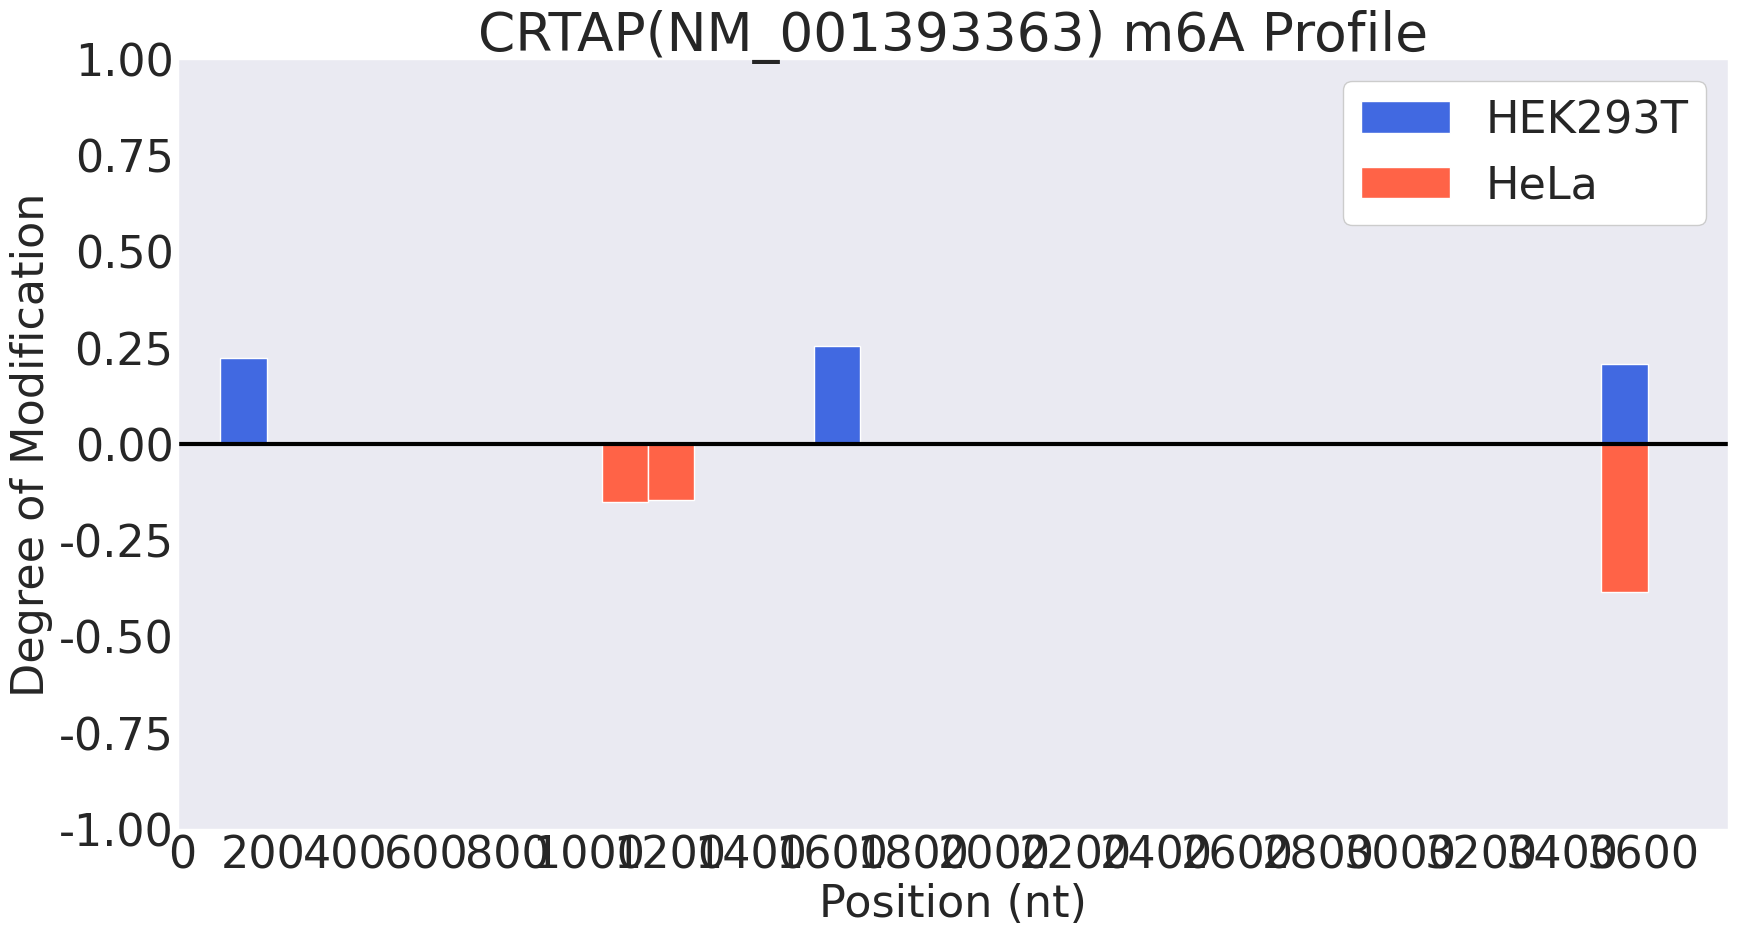

NM_130766


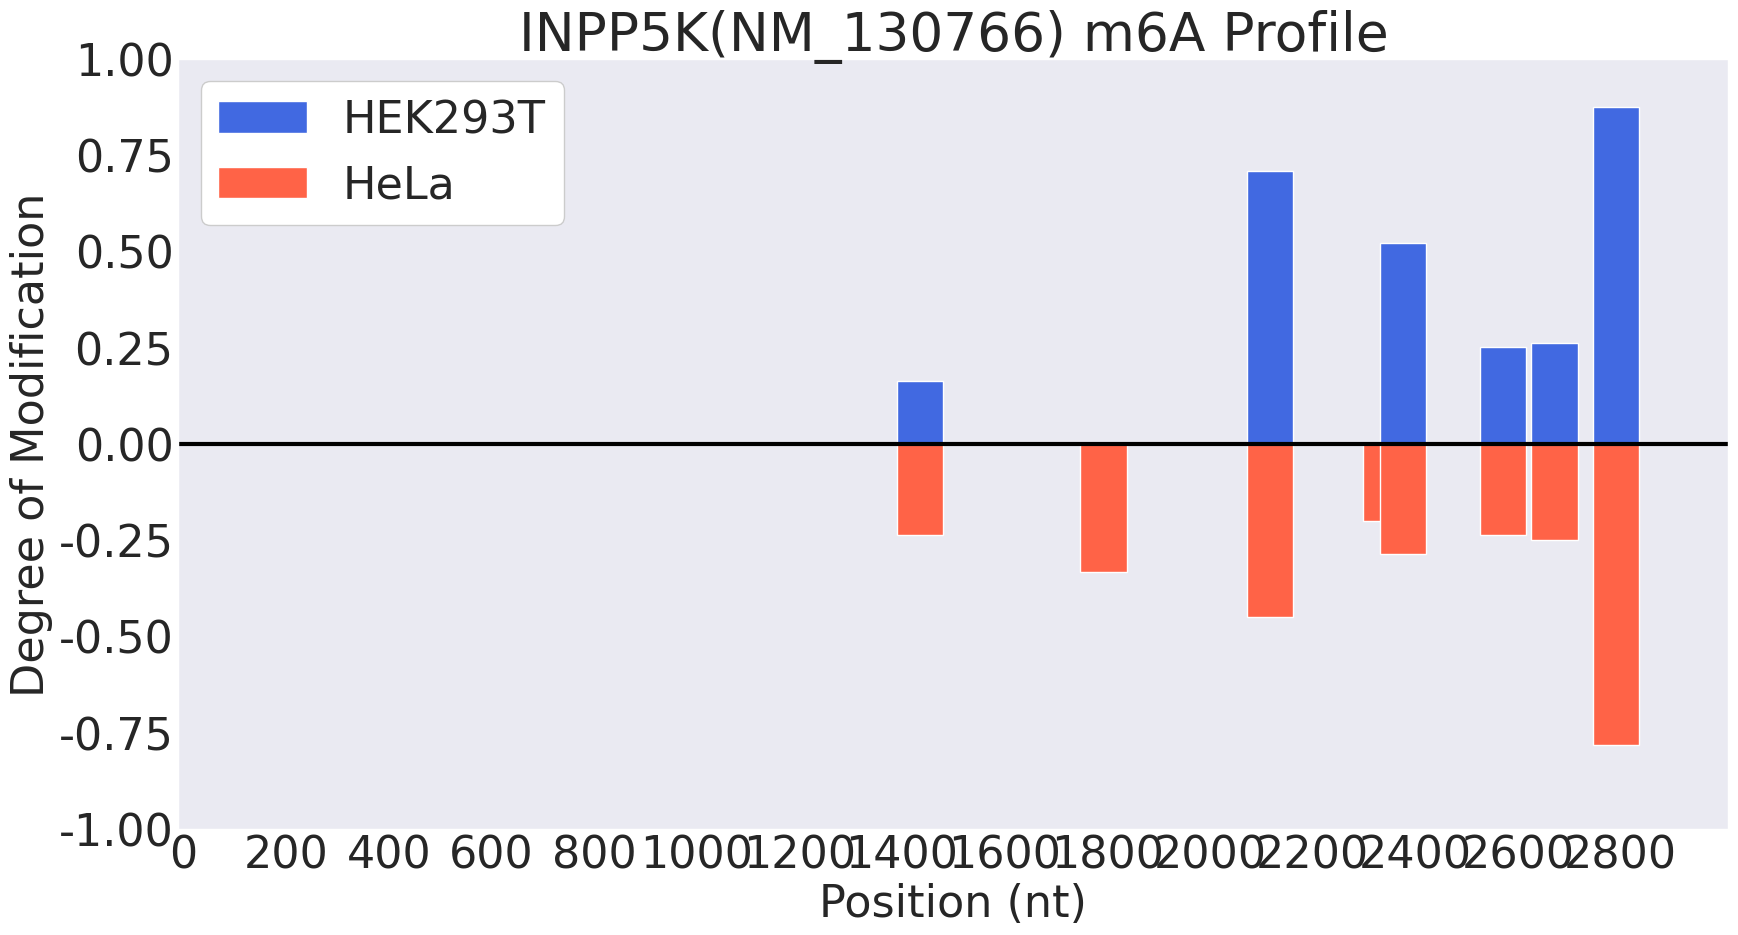

NM_001376077


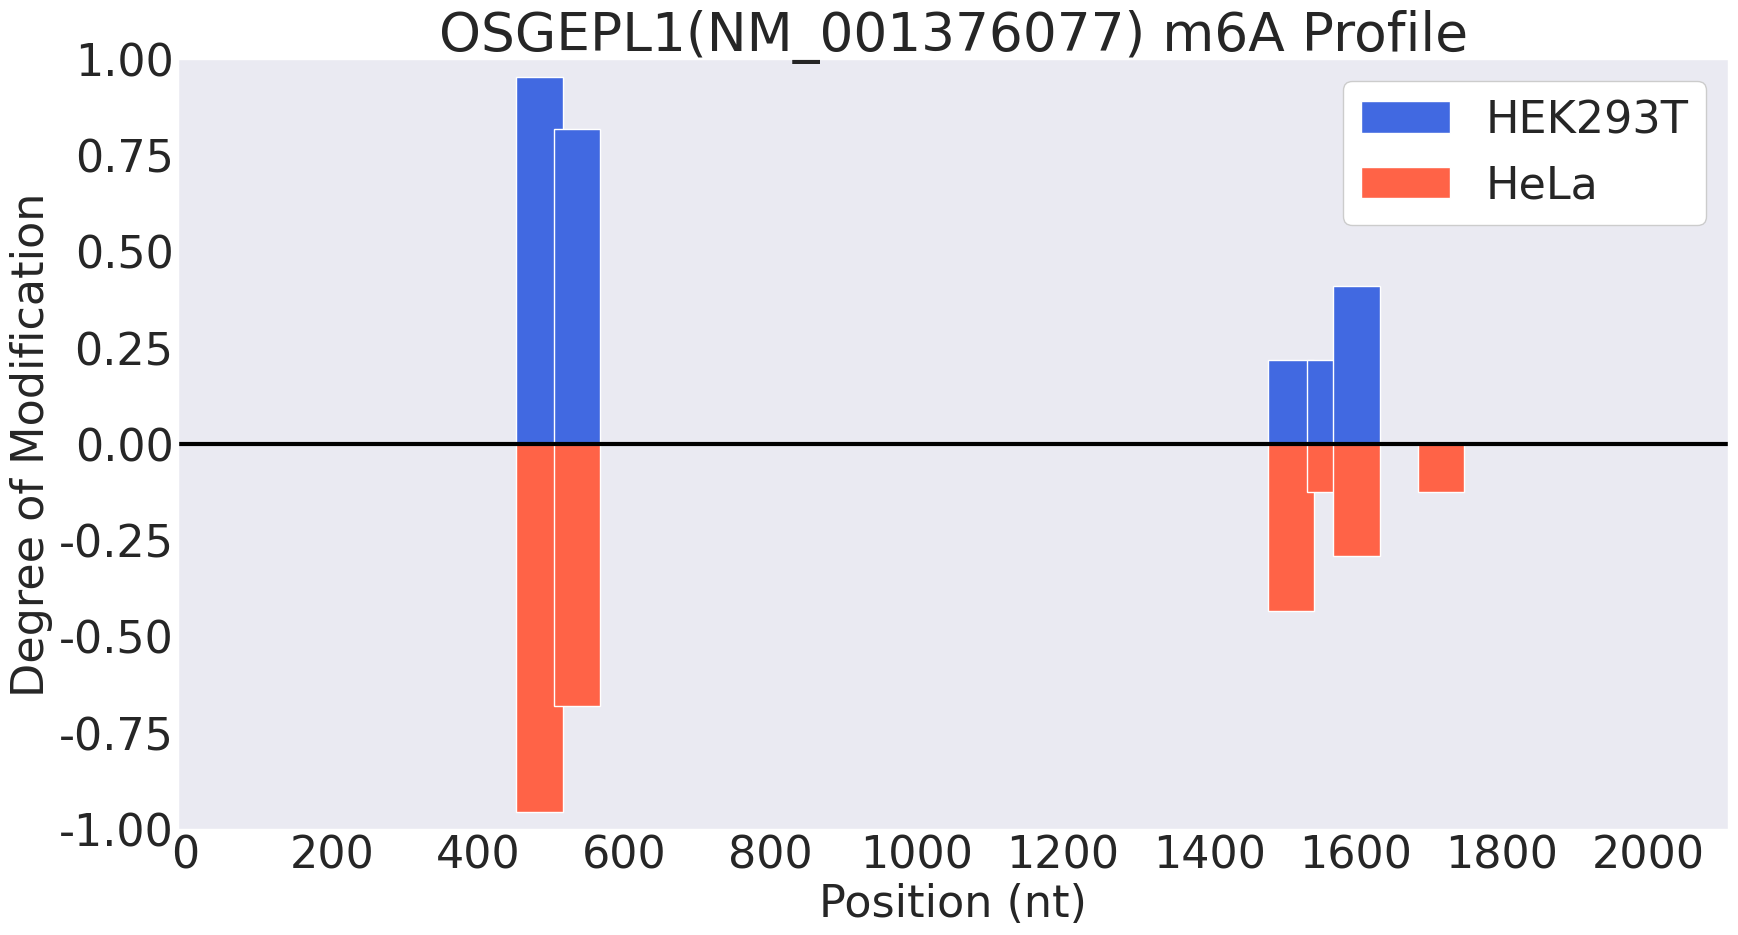

NM_001286797


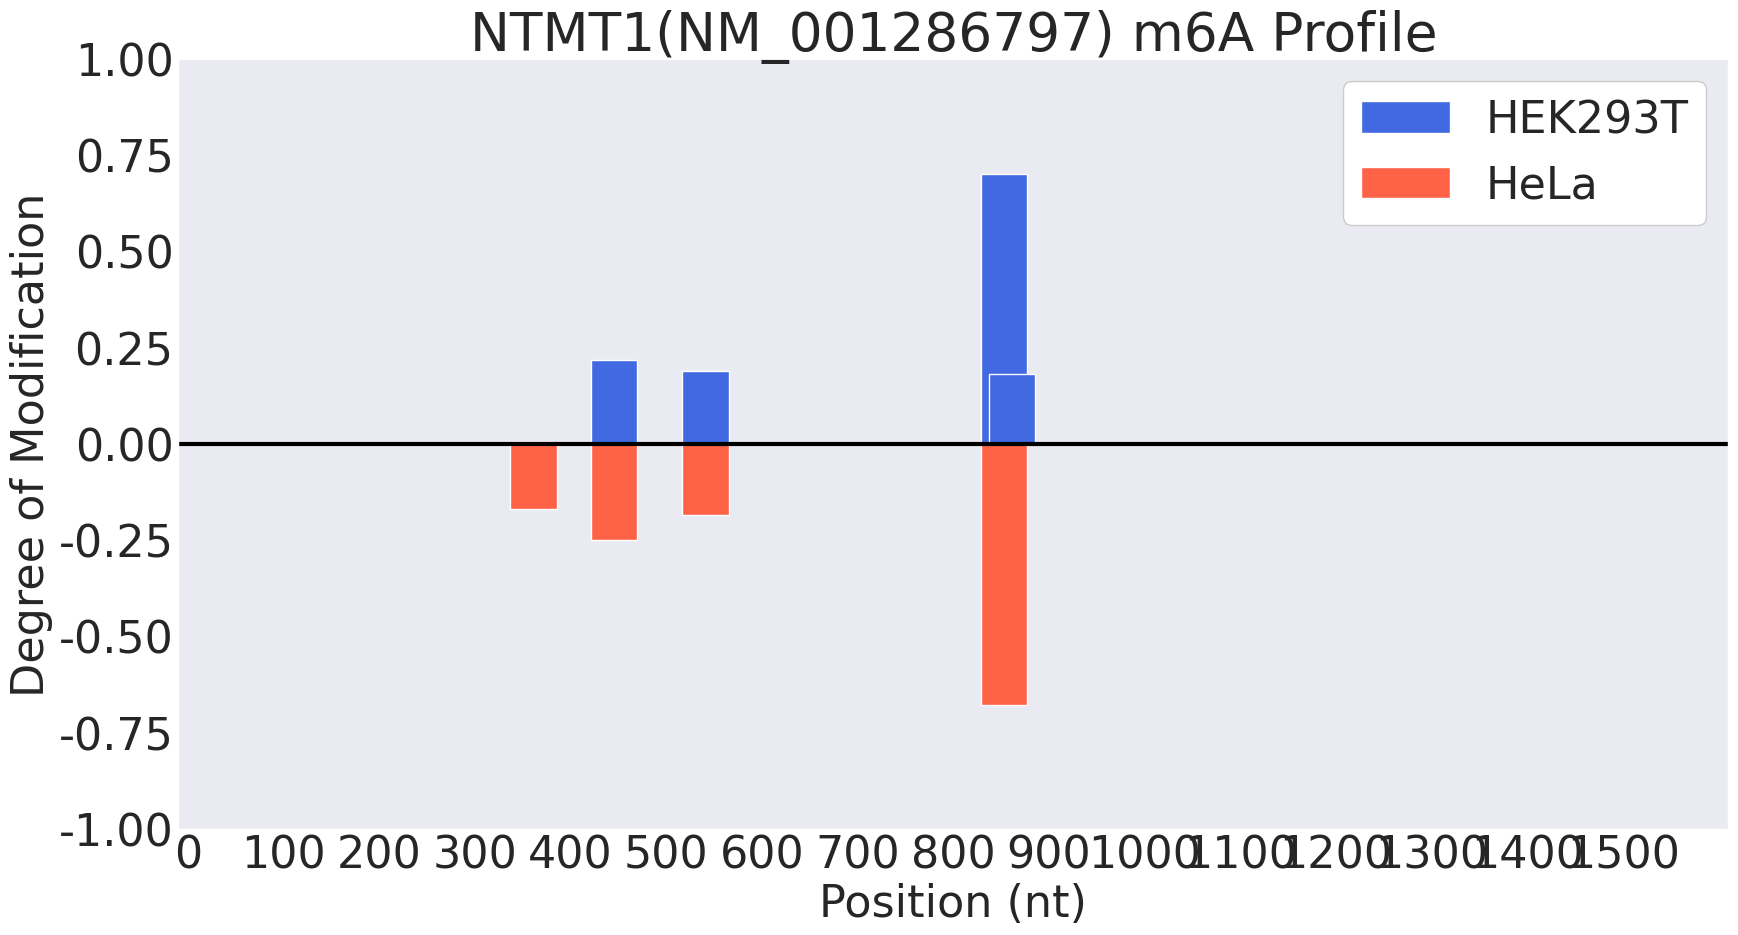

NM_022832


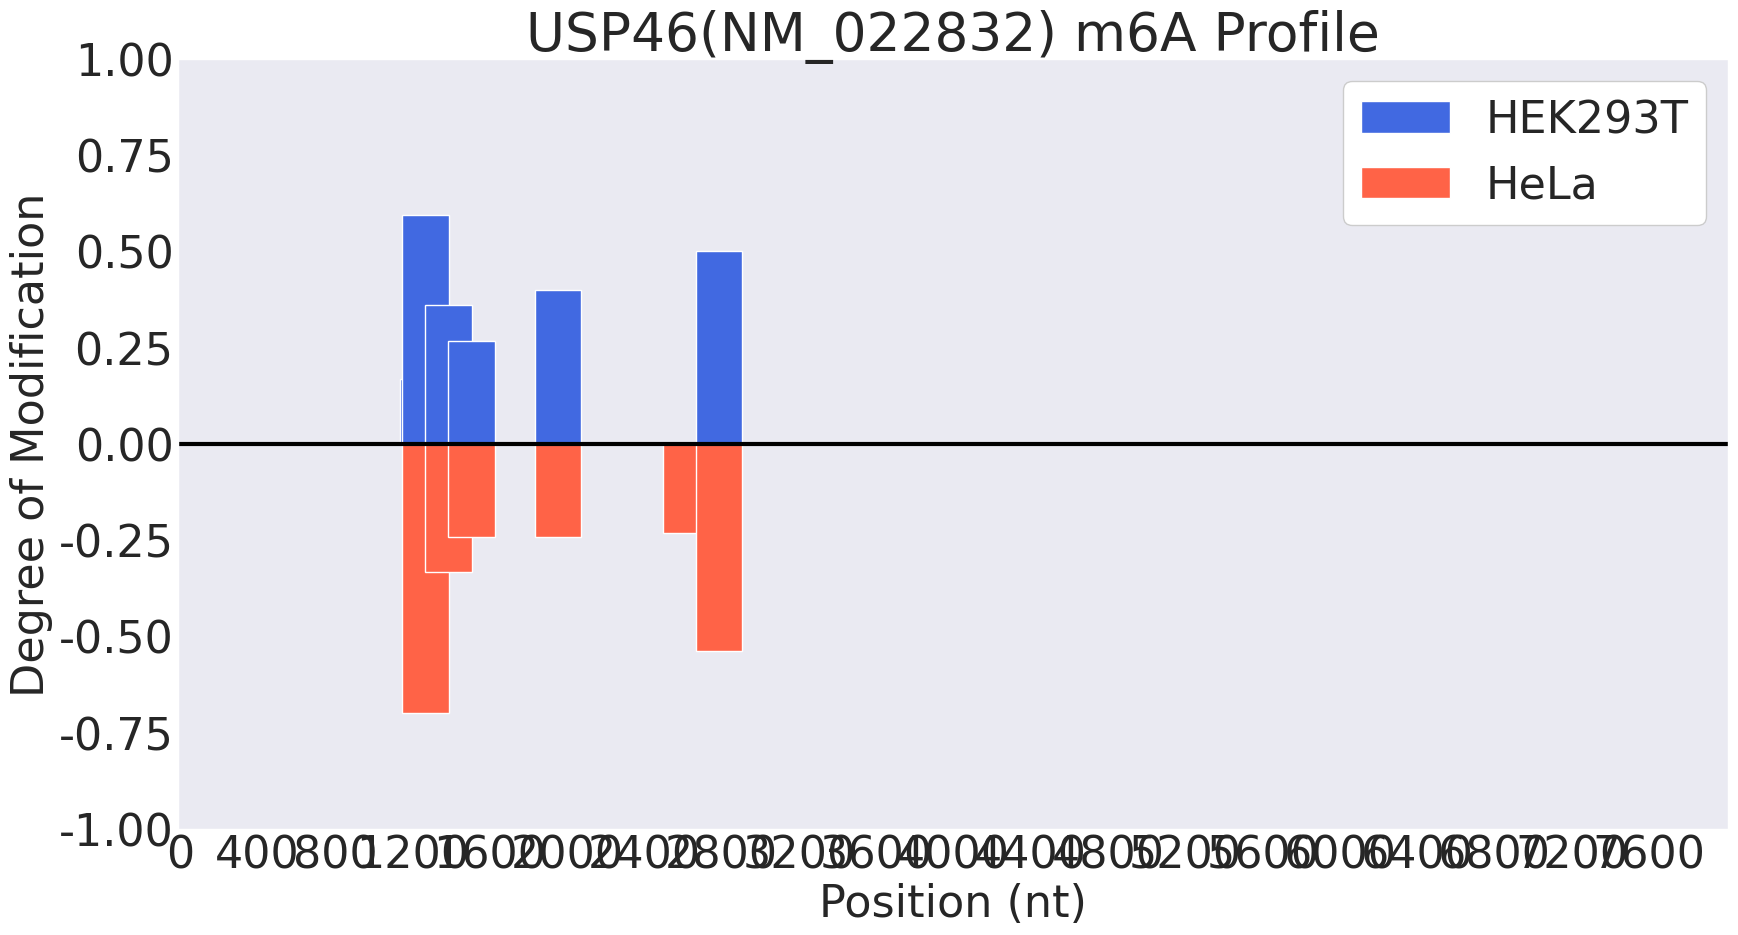

NM_020381


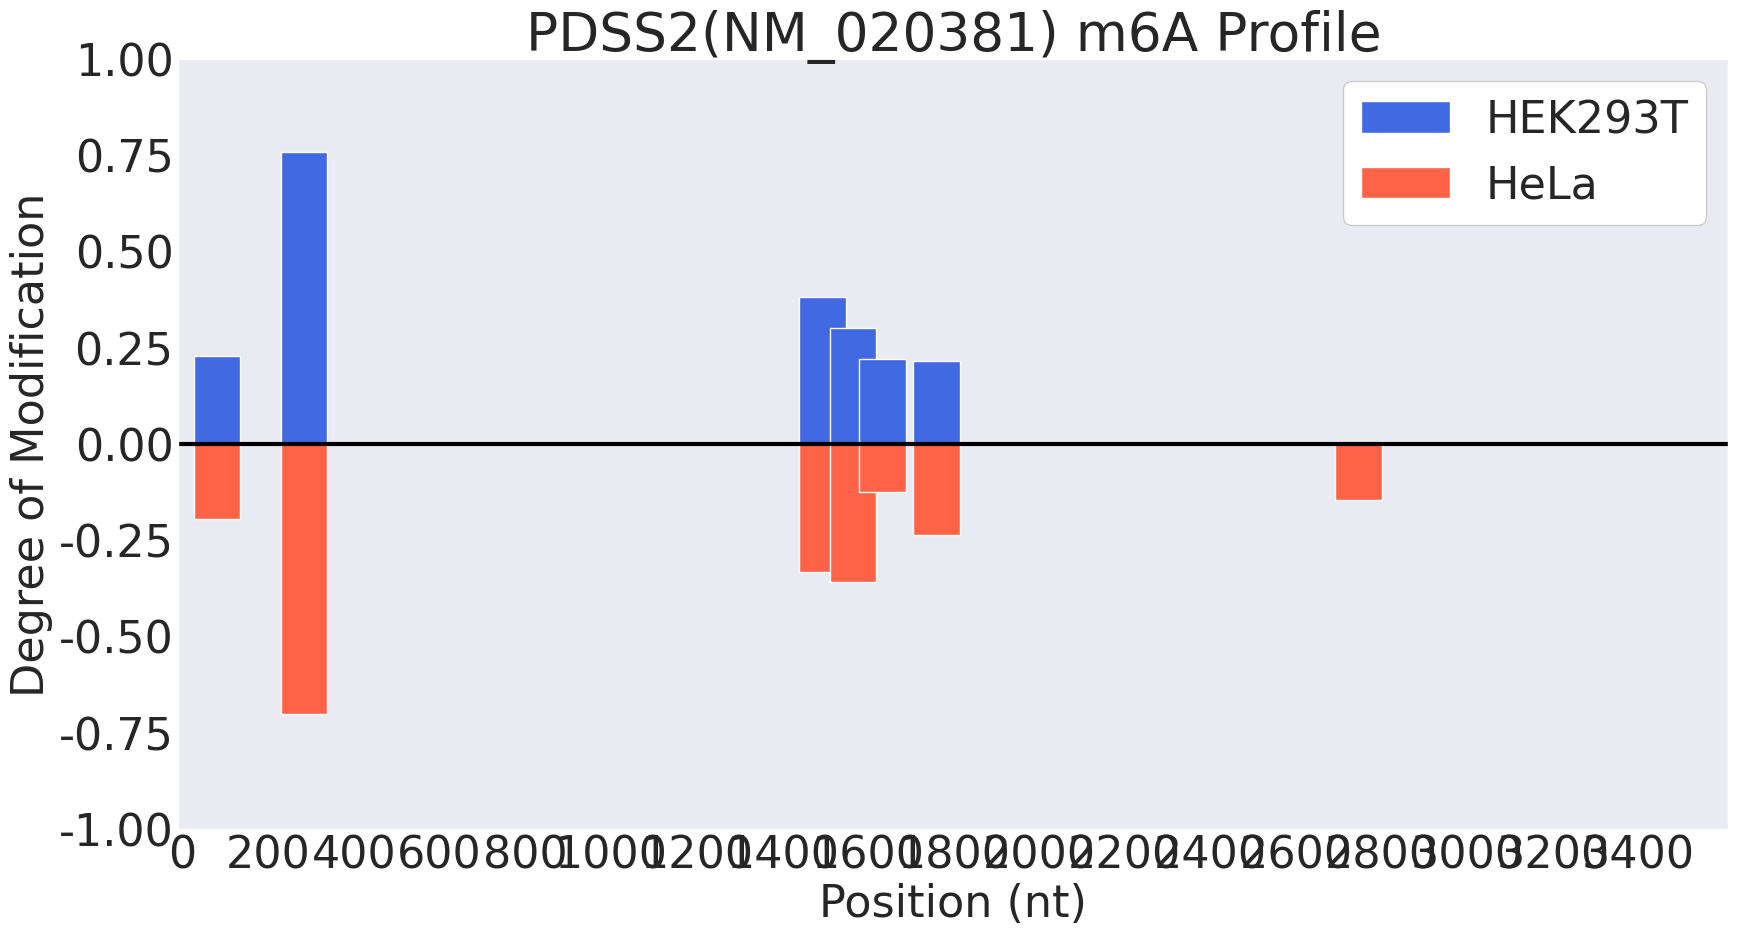

NM_001102


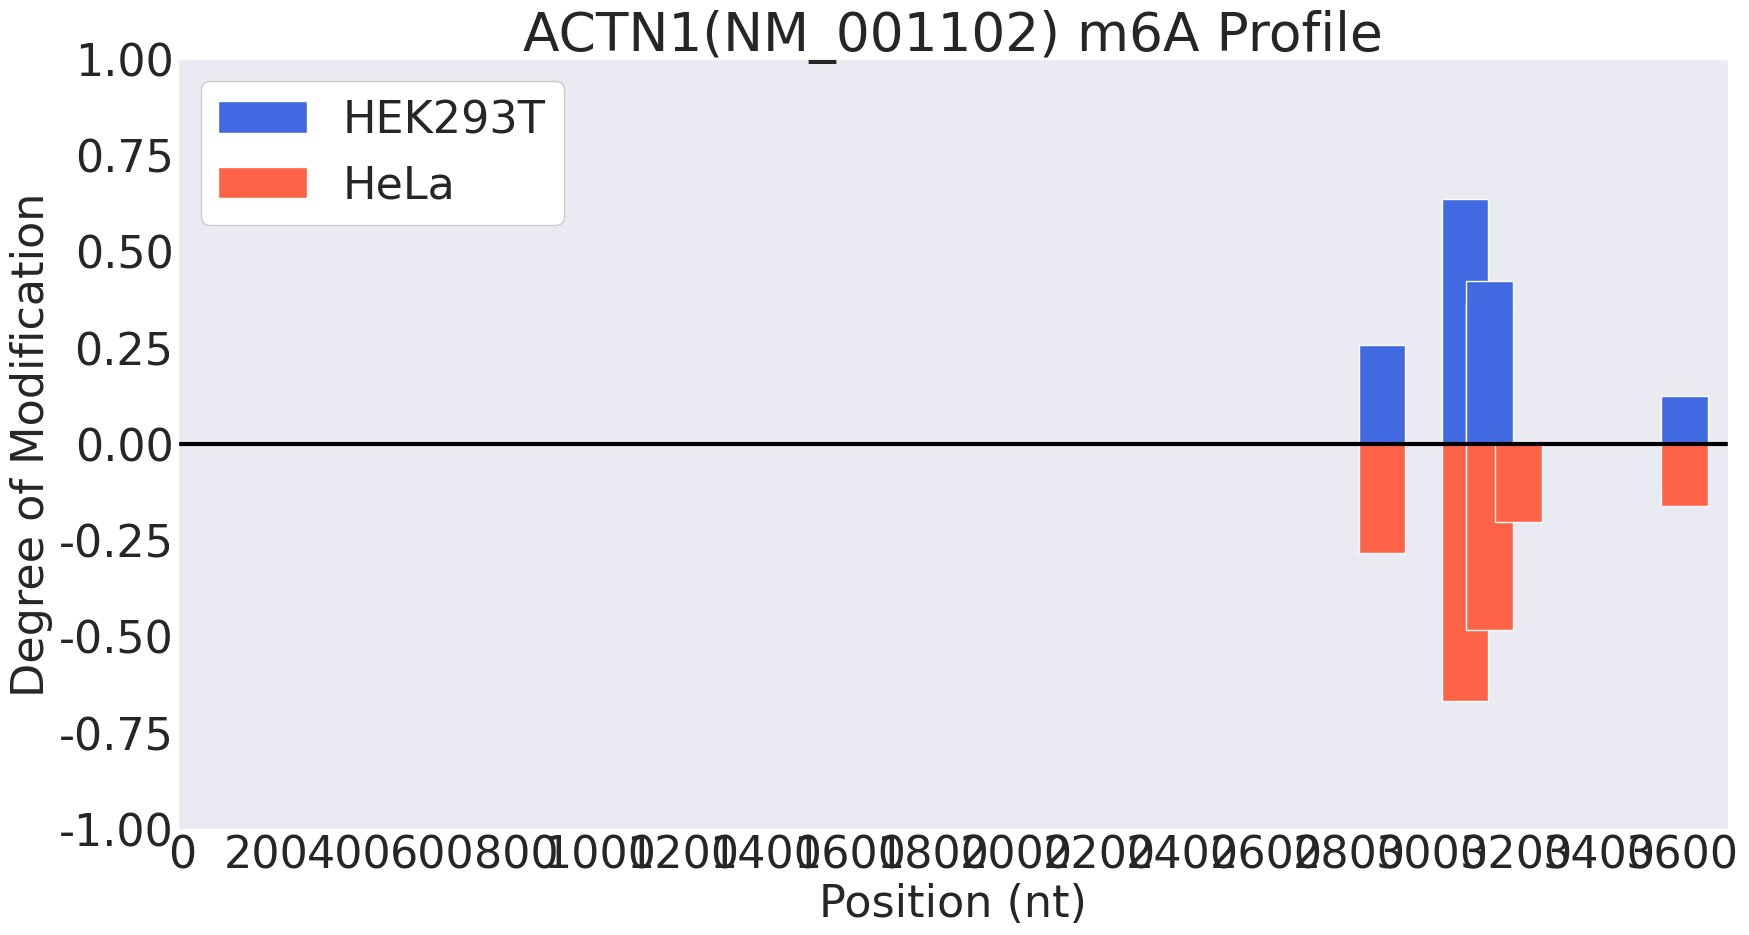

NM_001320581


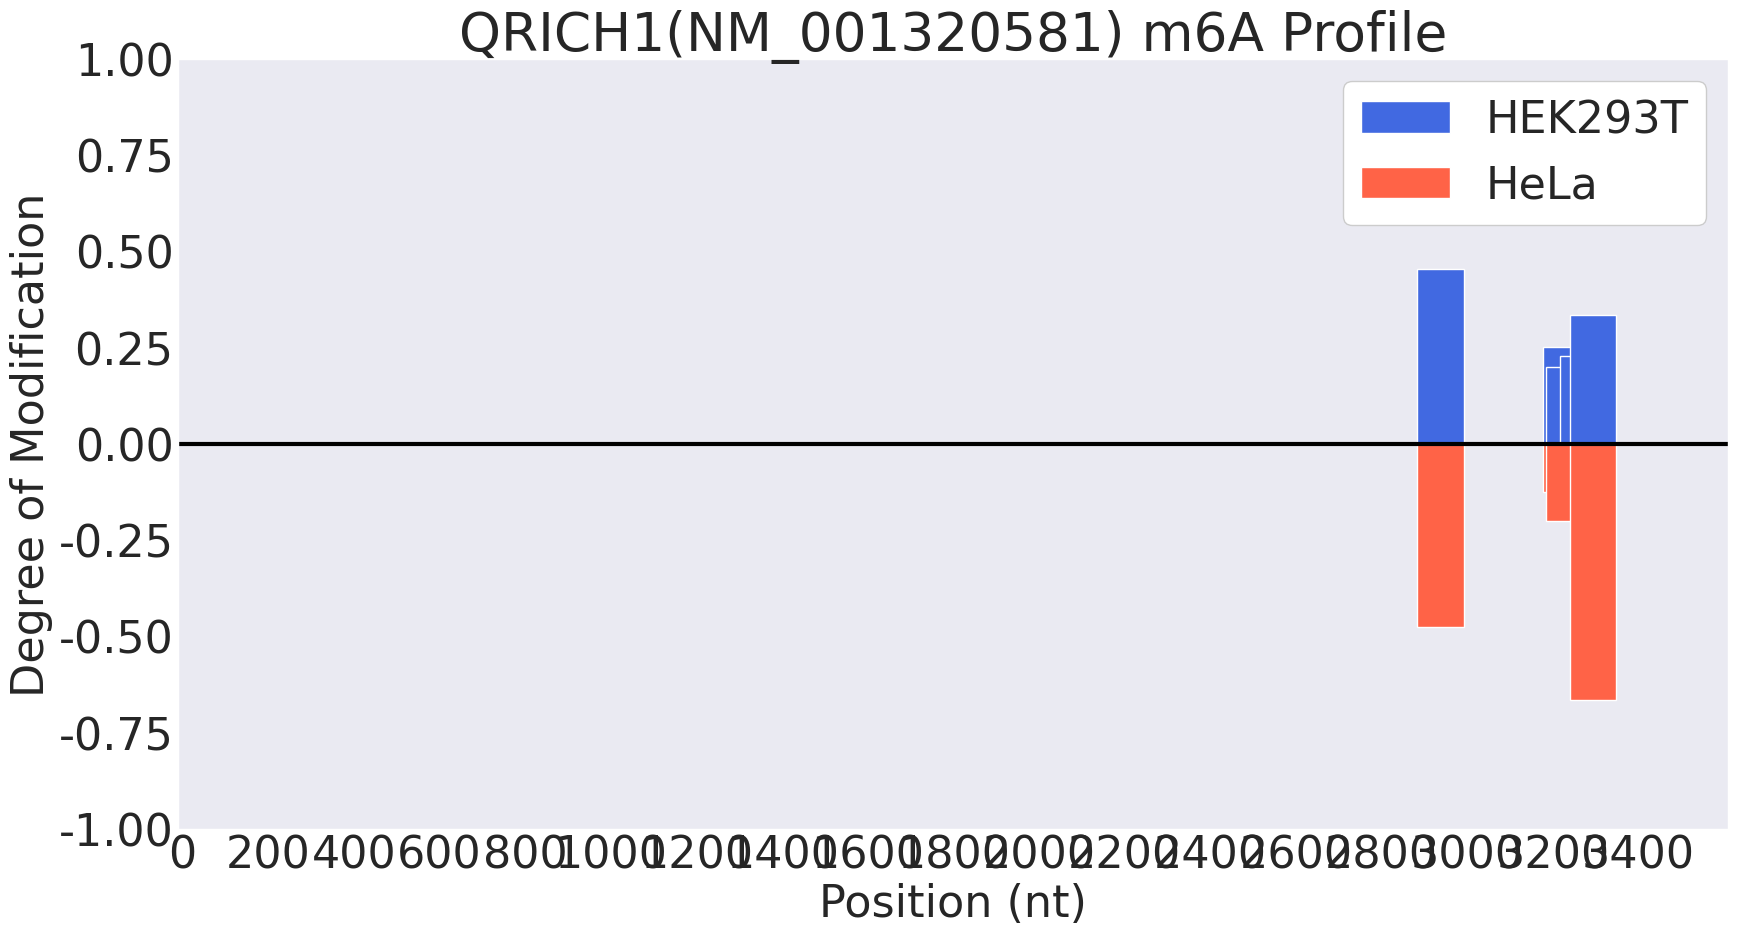

NM_198527


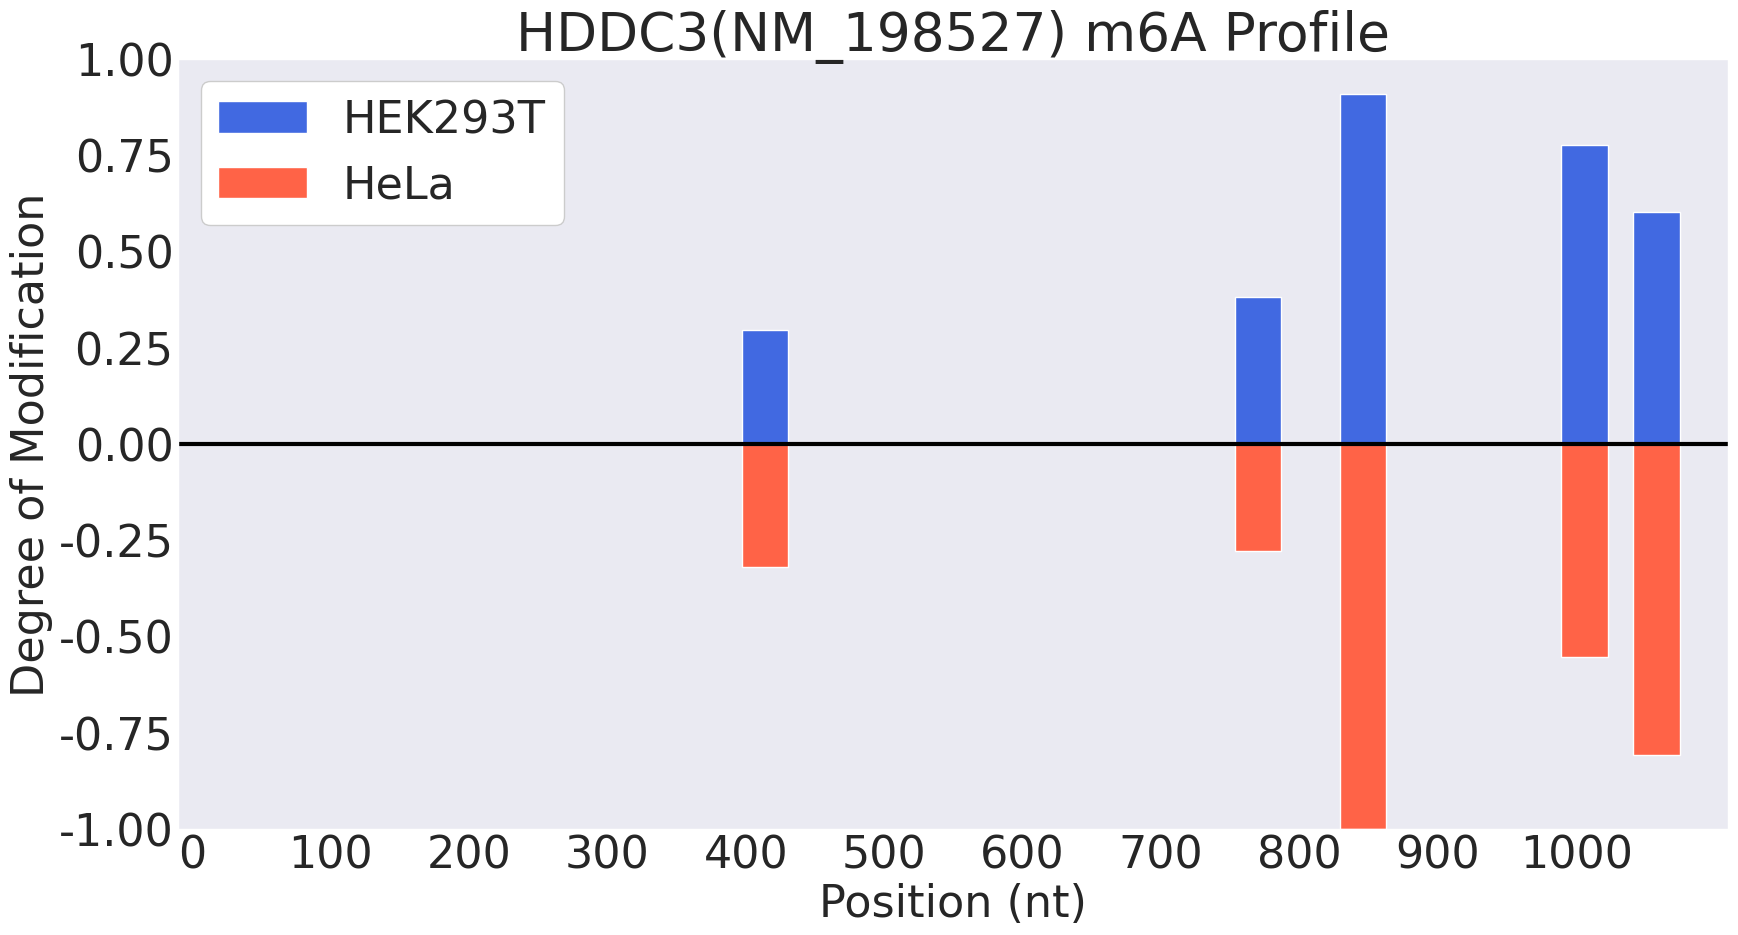

NM_032493


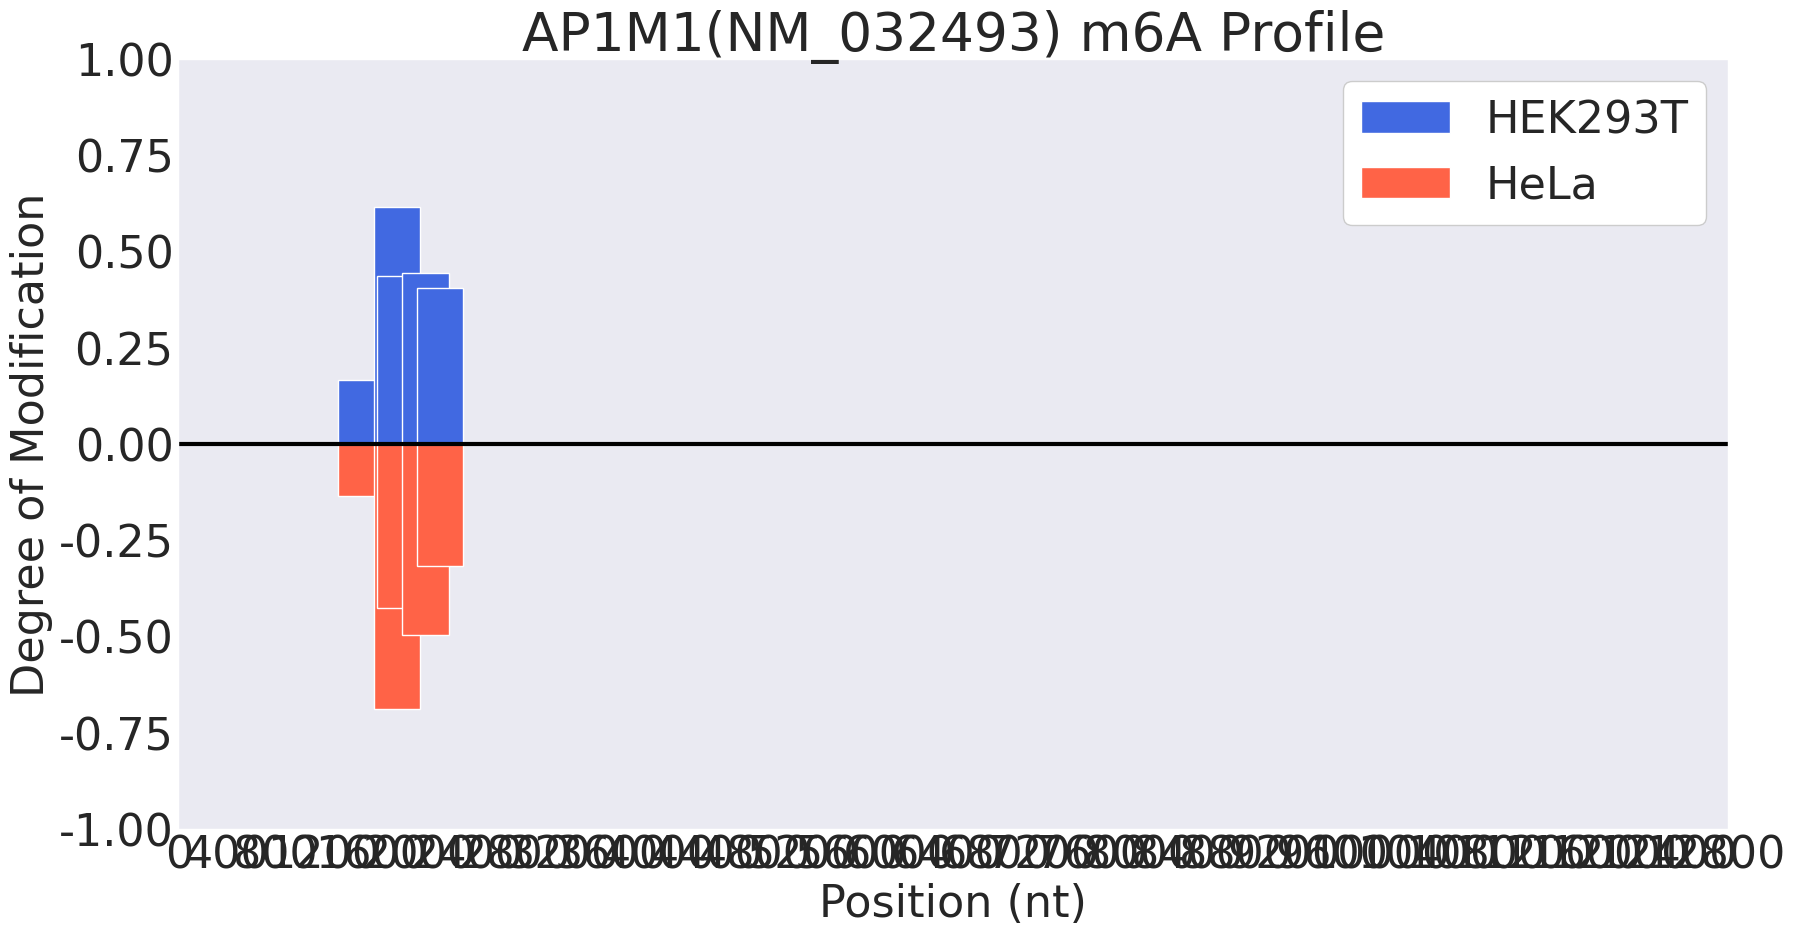

NM_001007075


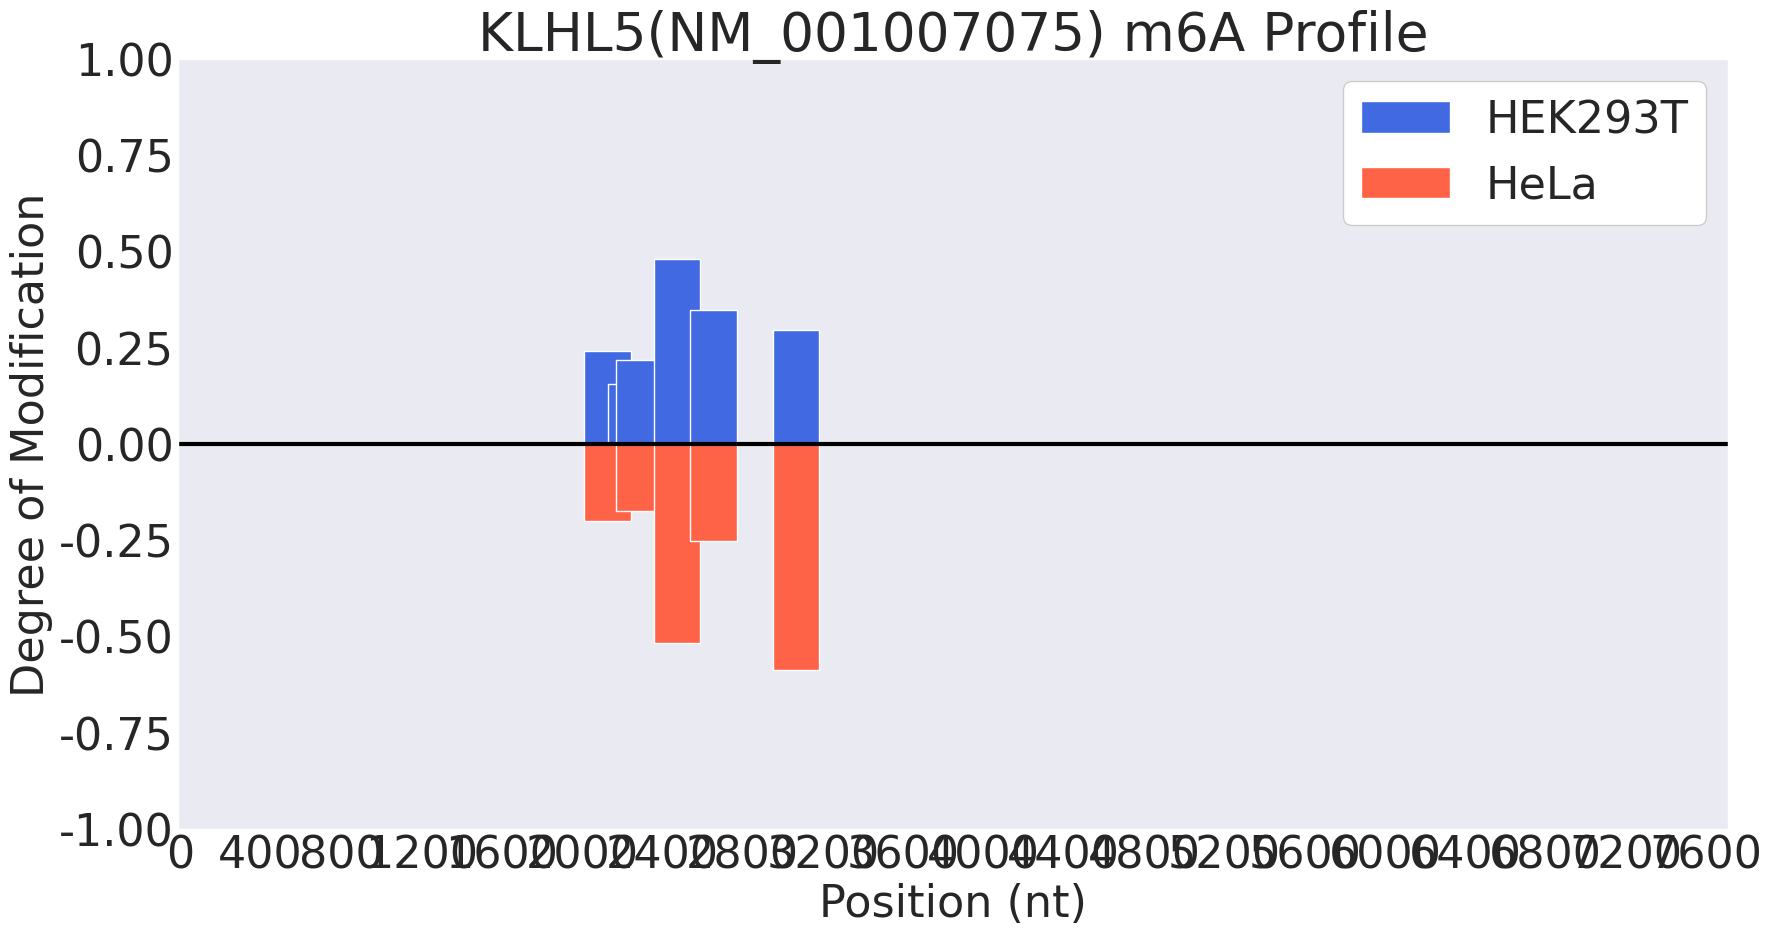

NM_007007


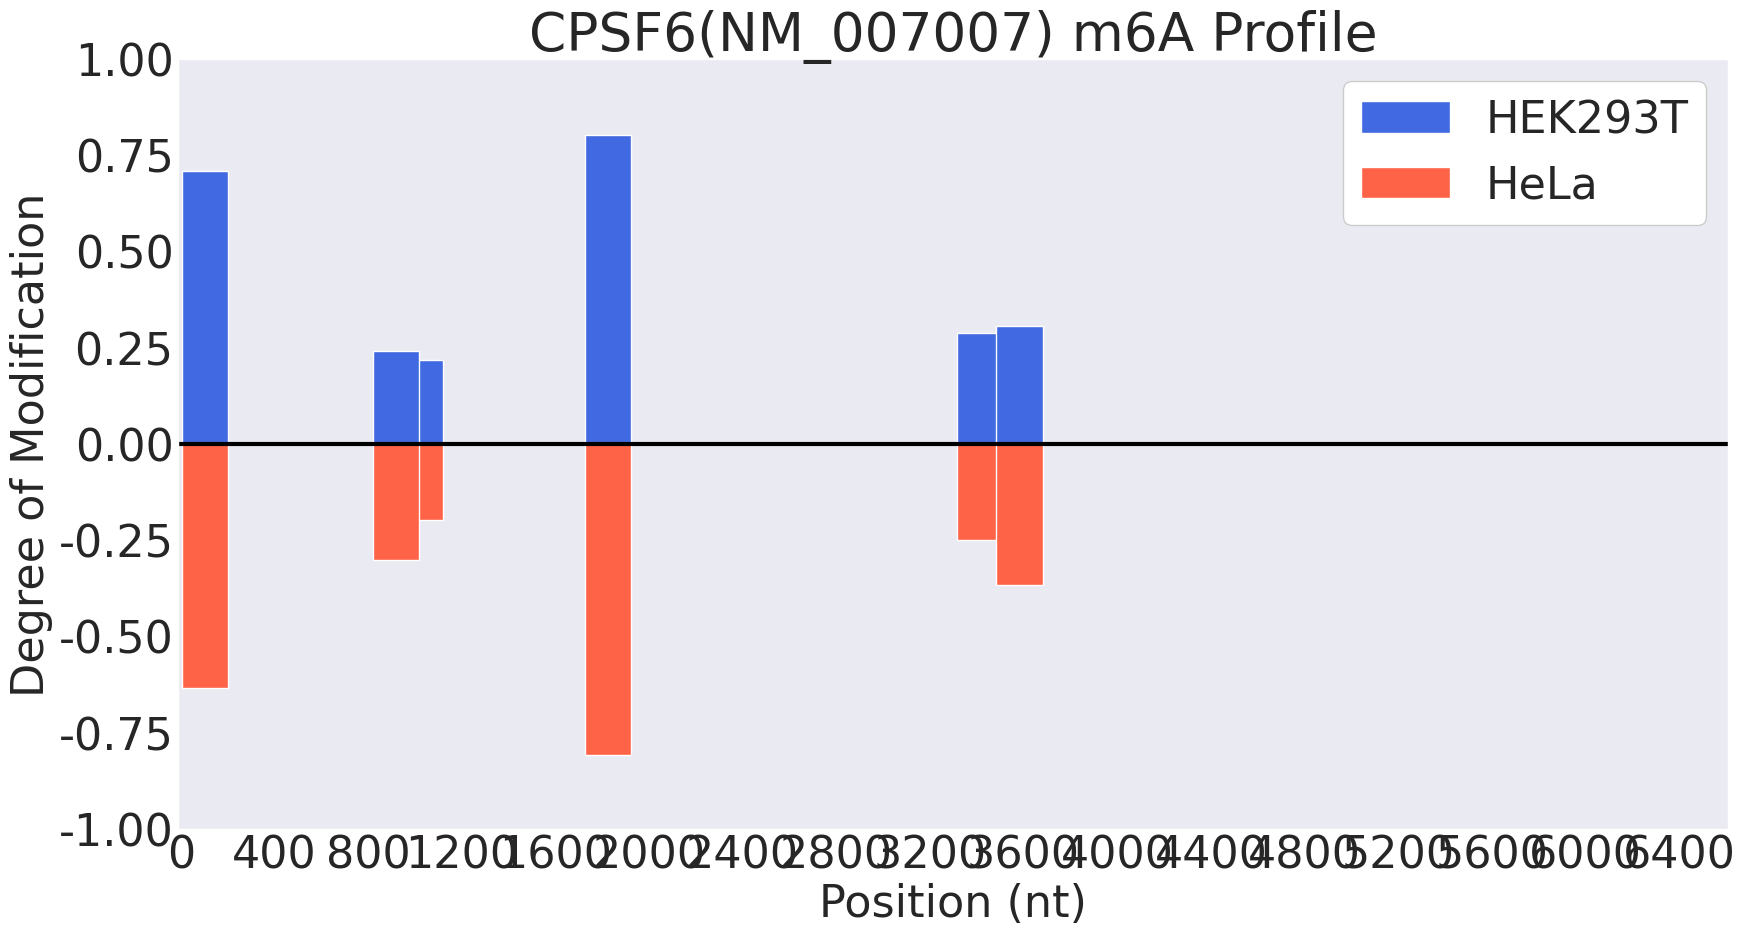

NM_139320


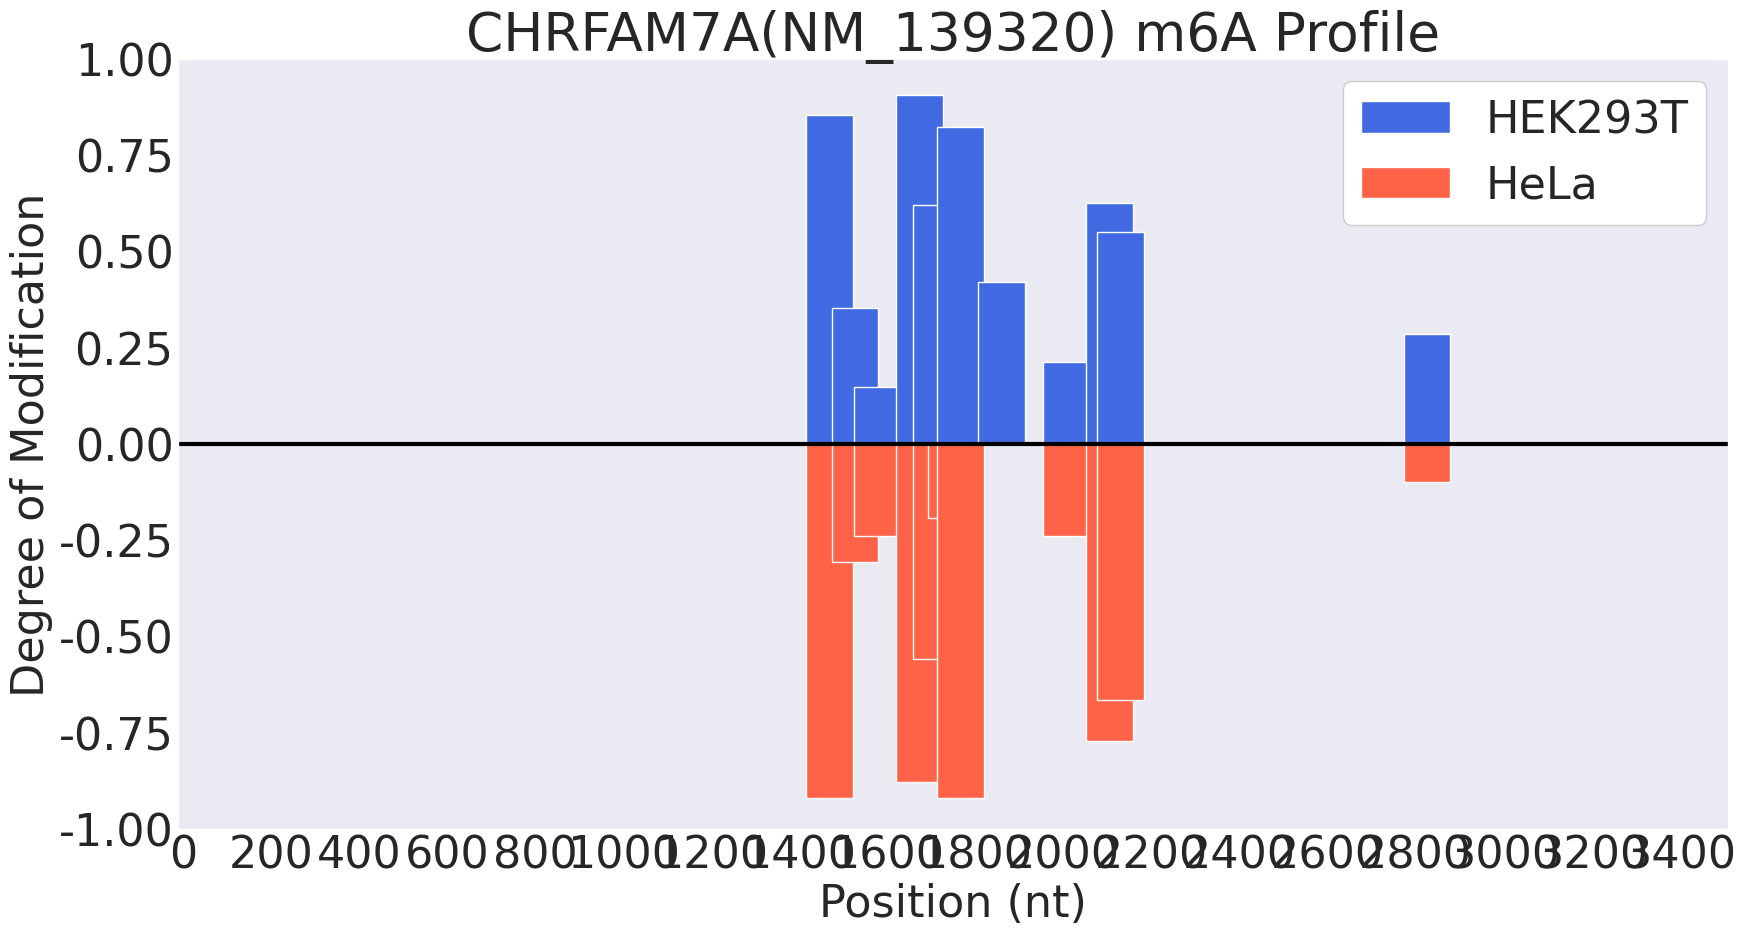

NM_001136574


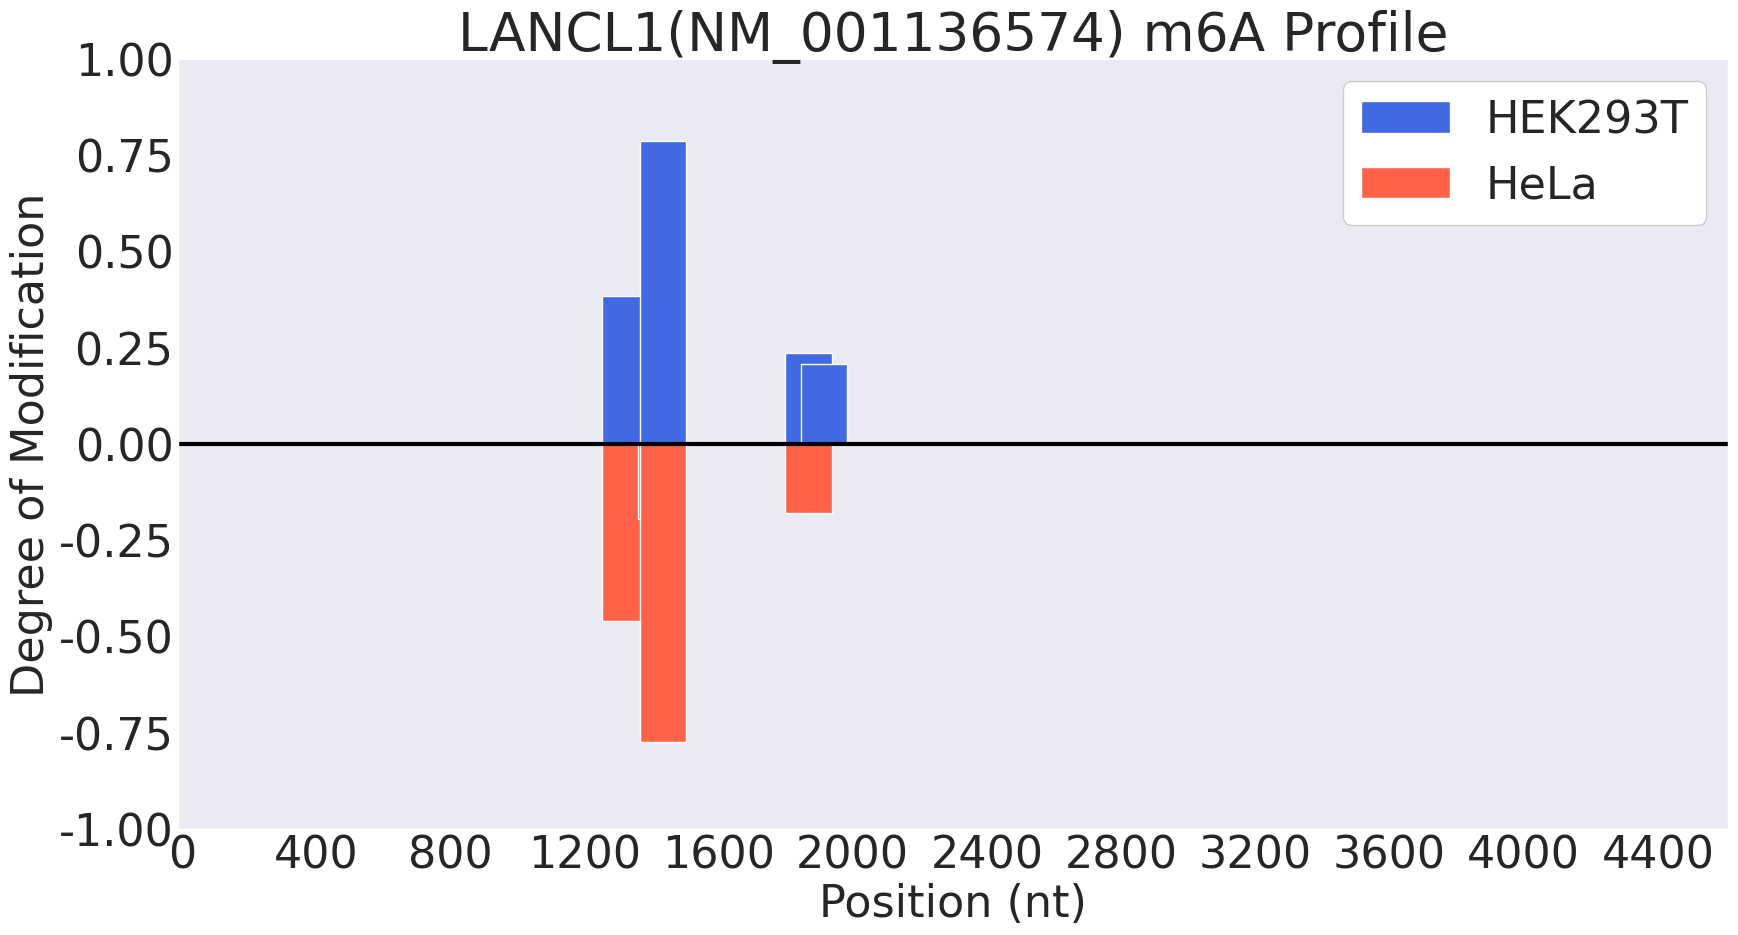

NM_001048249


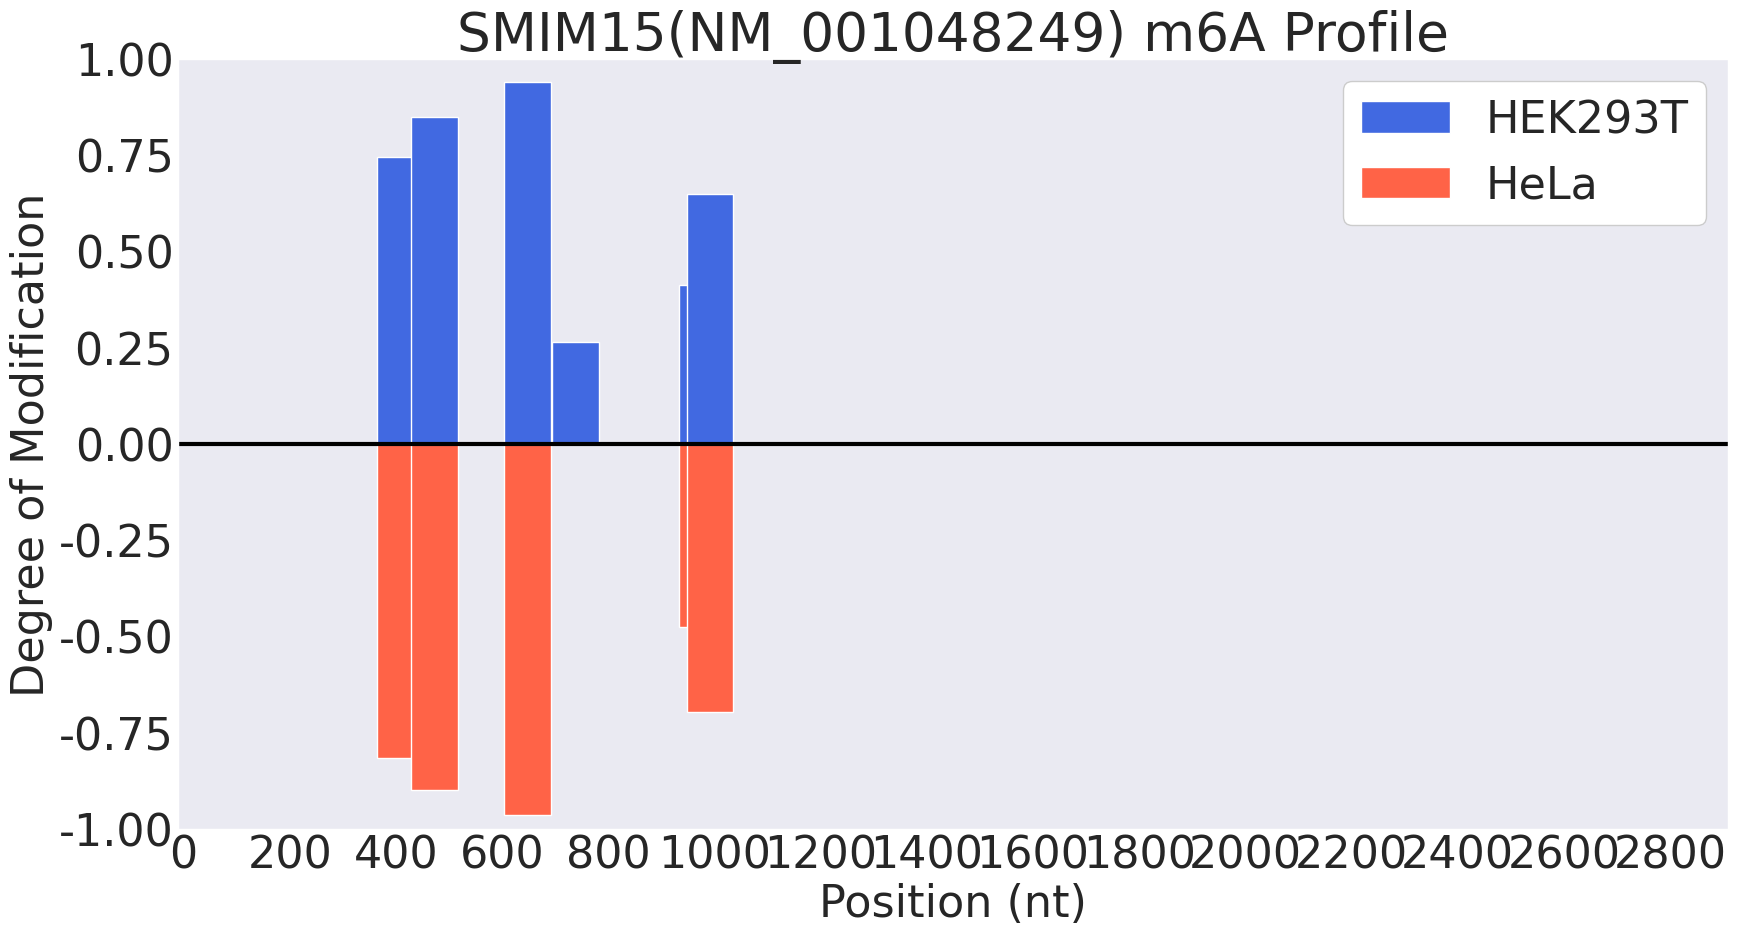

NM_018248


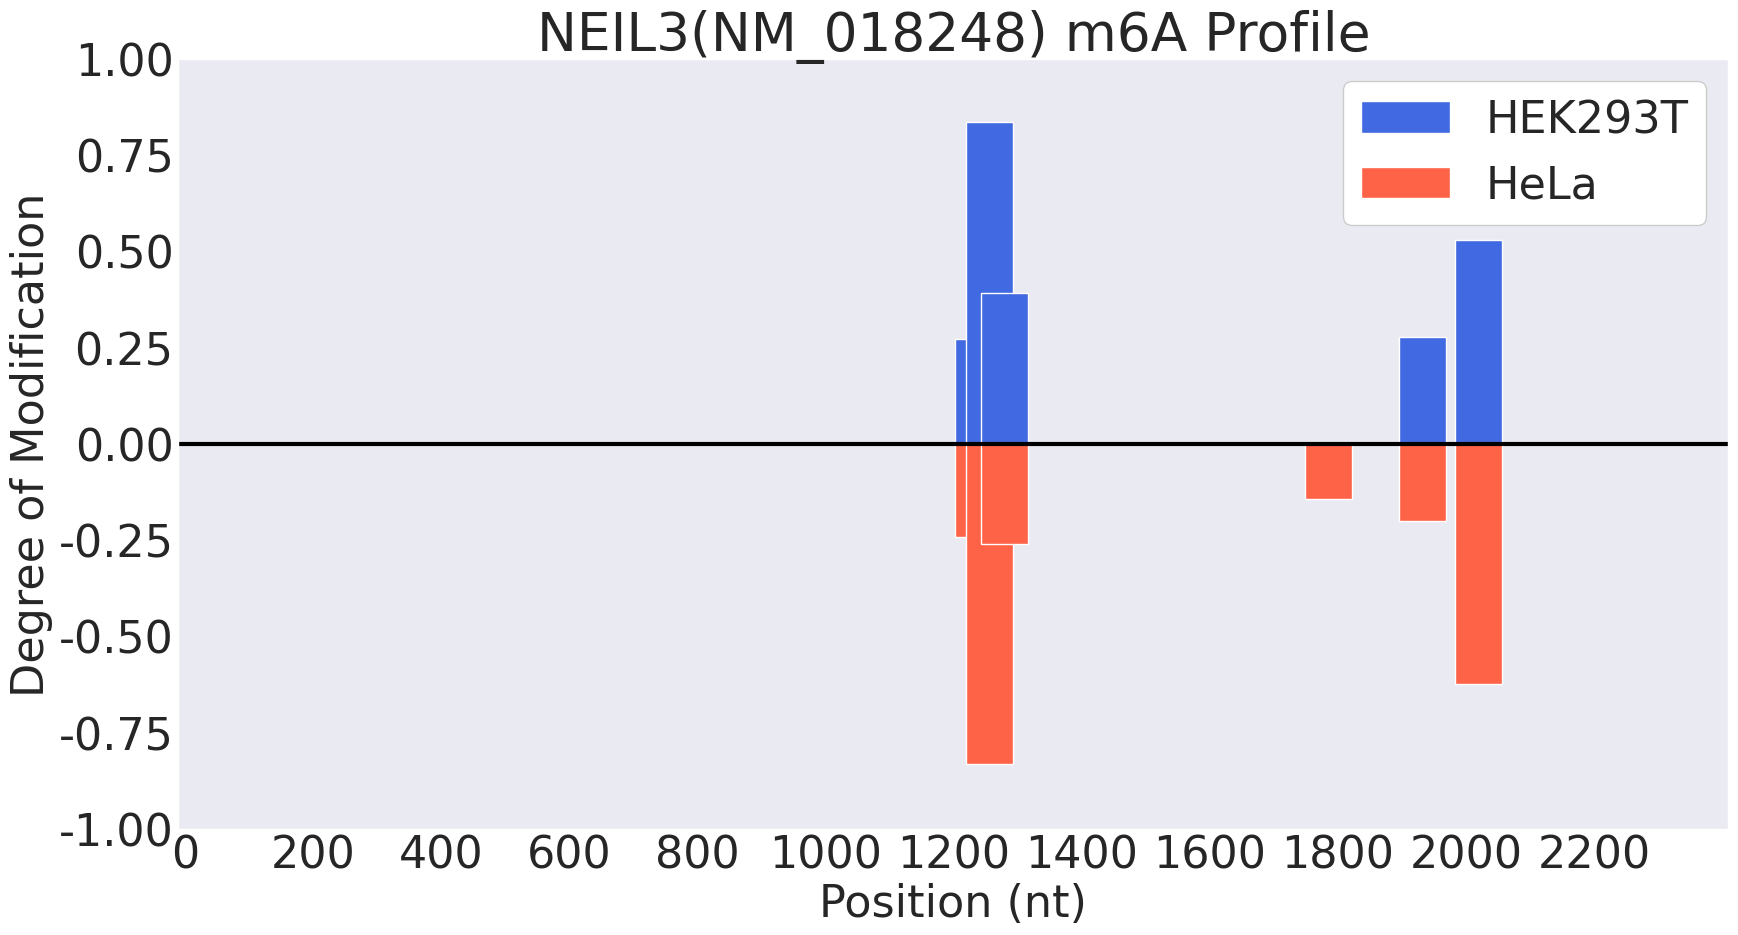

NM_006696


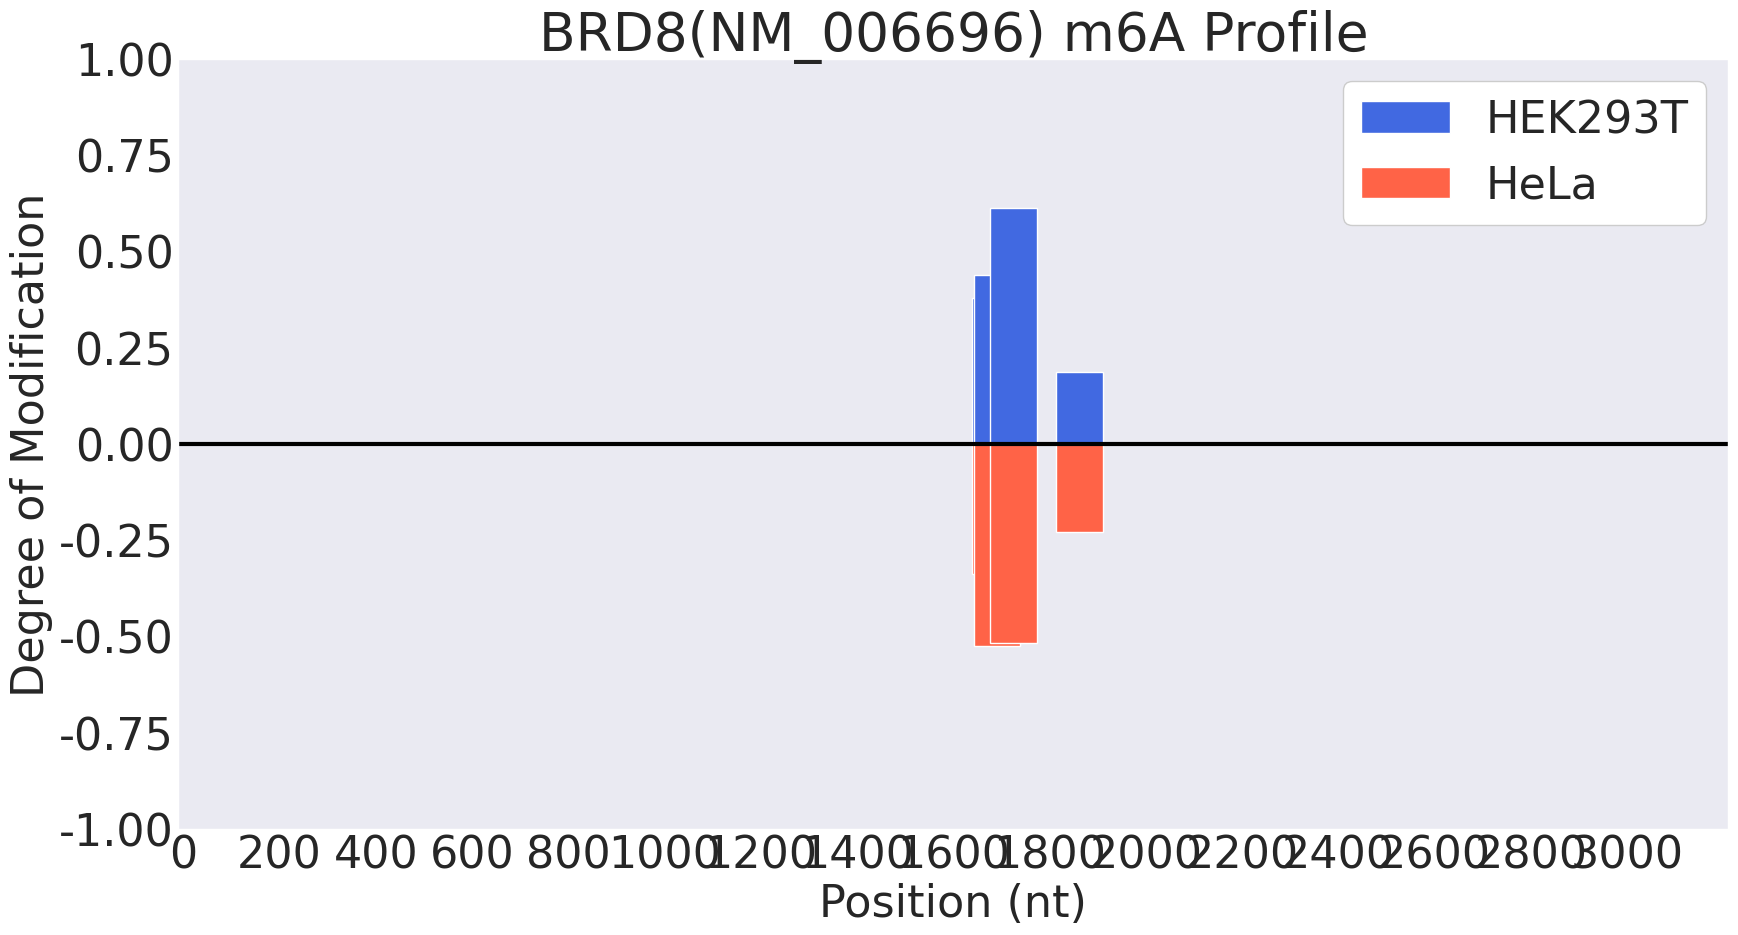

NM_031372


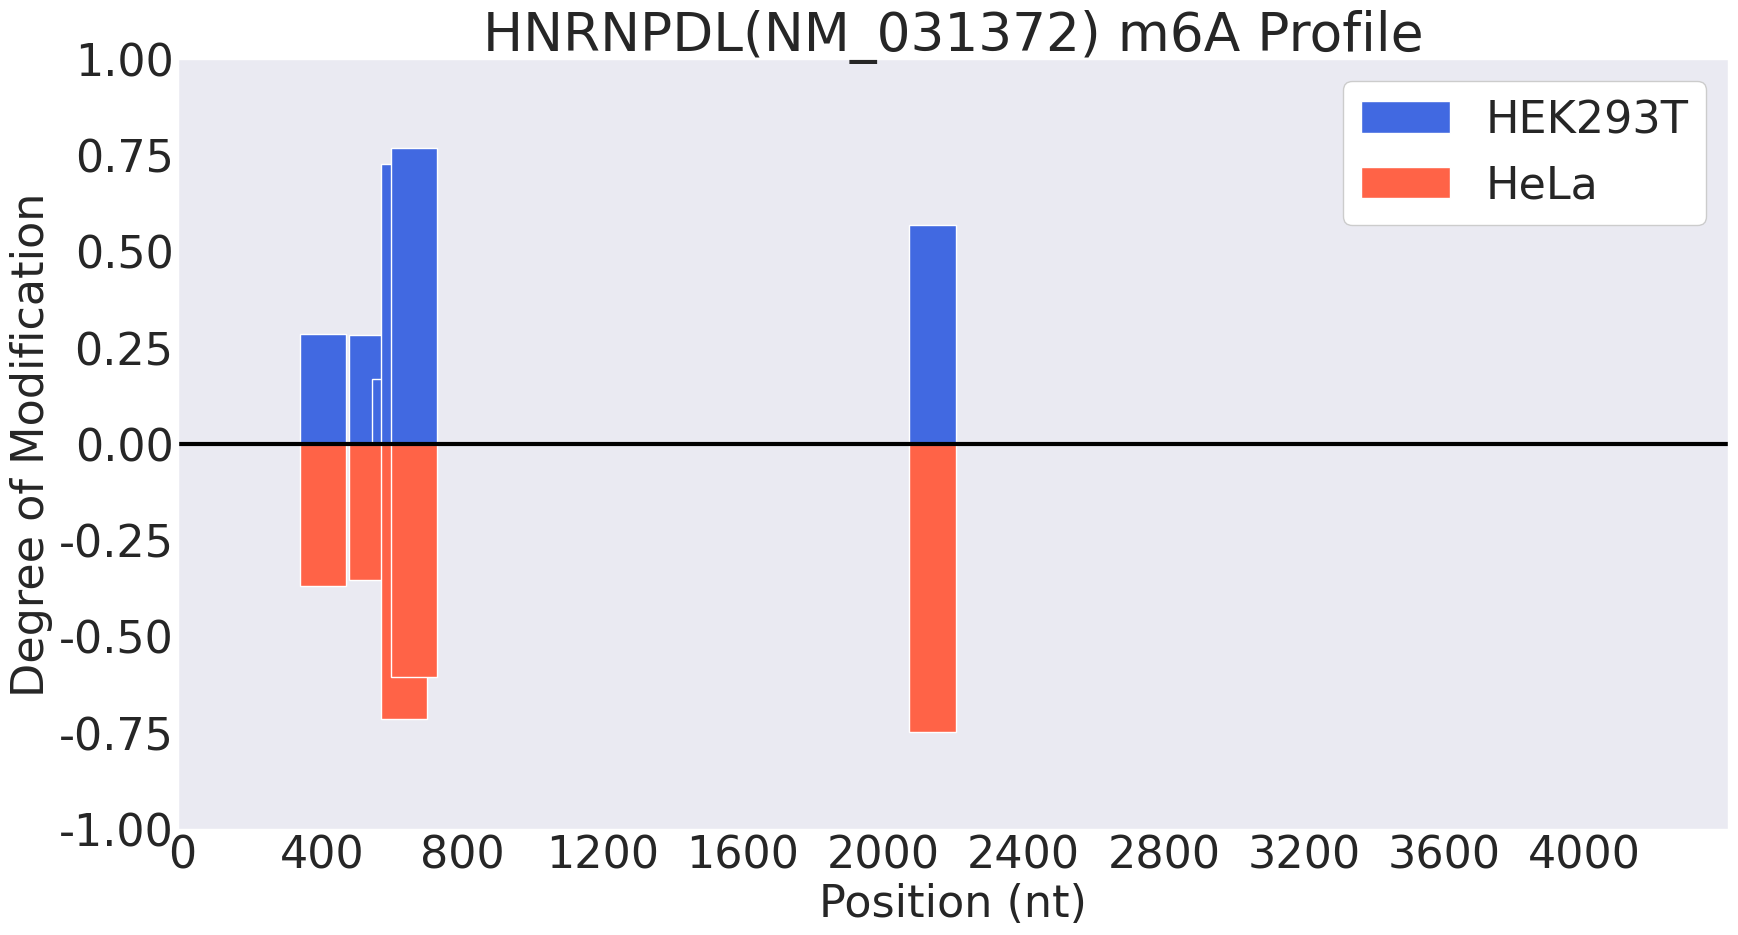

NM_001162384


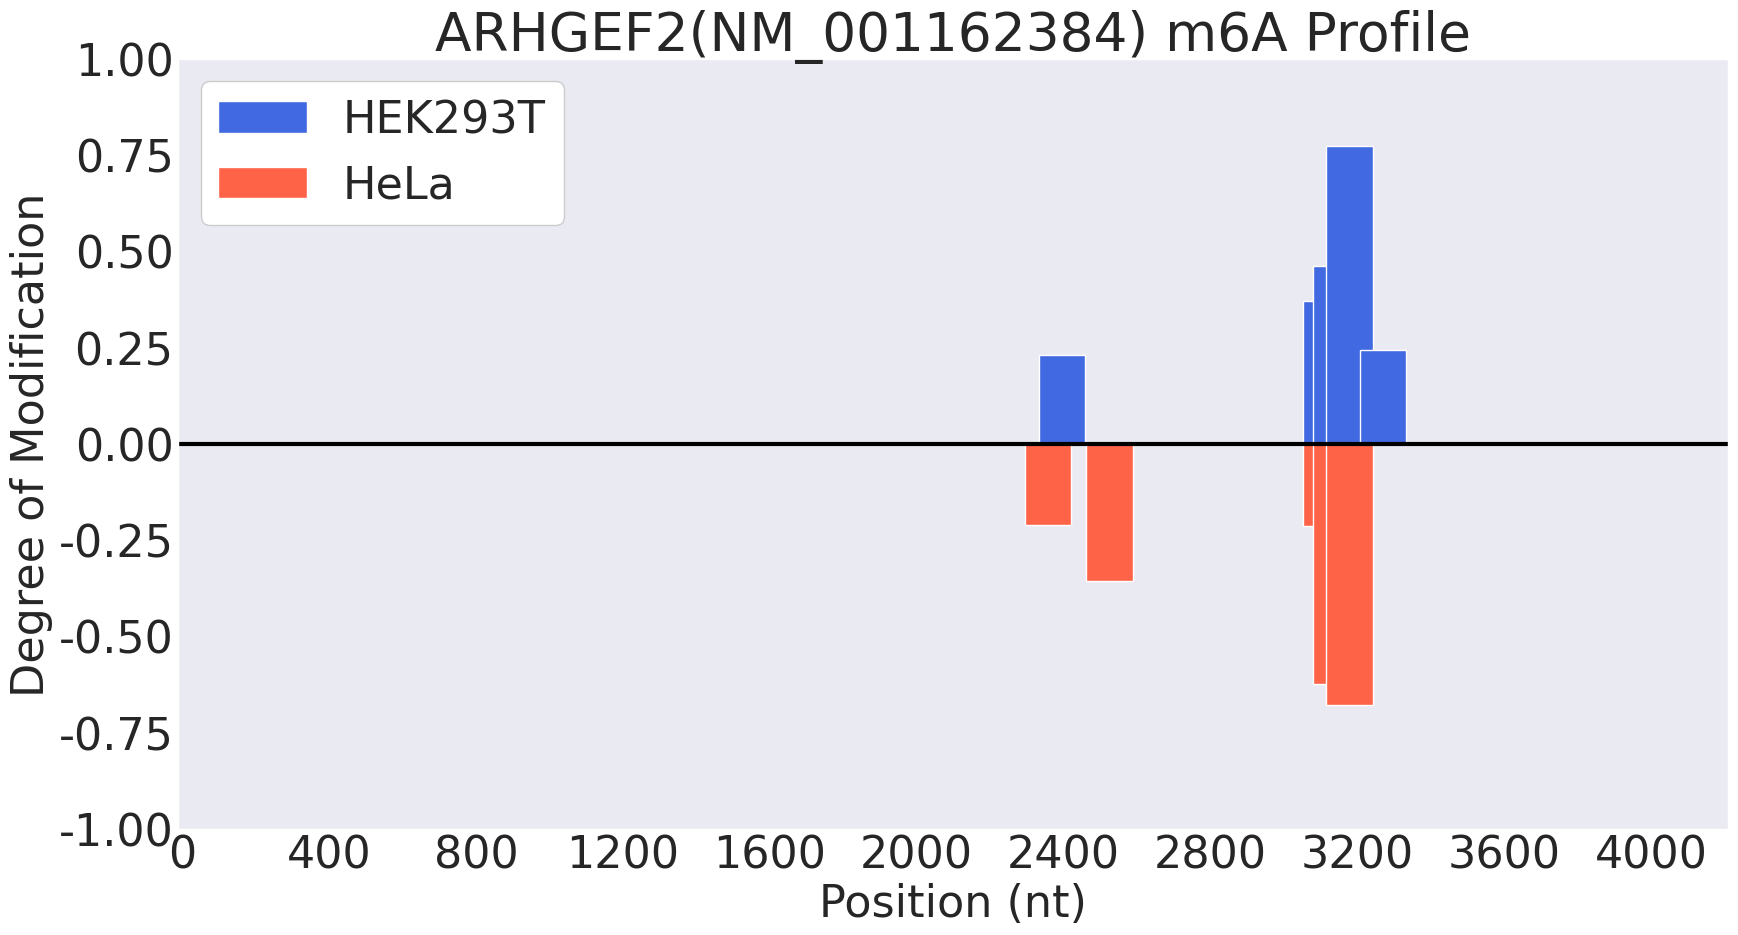

NM_001382430


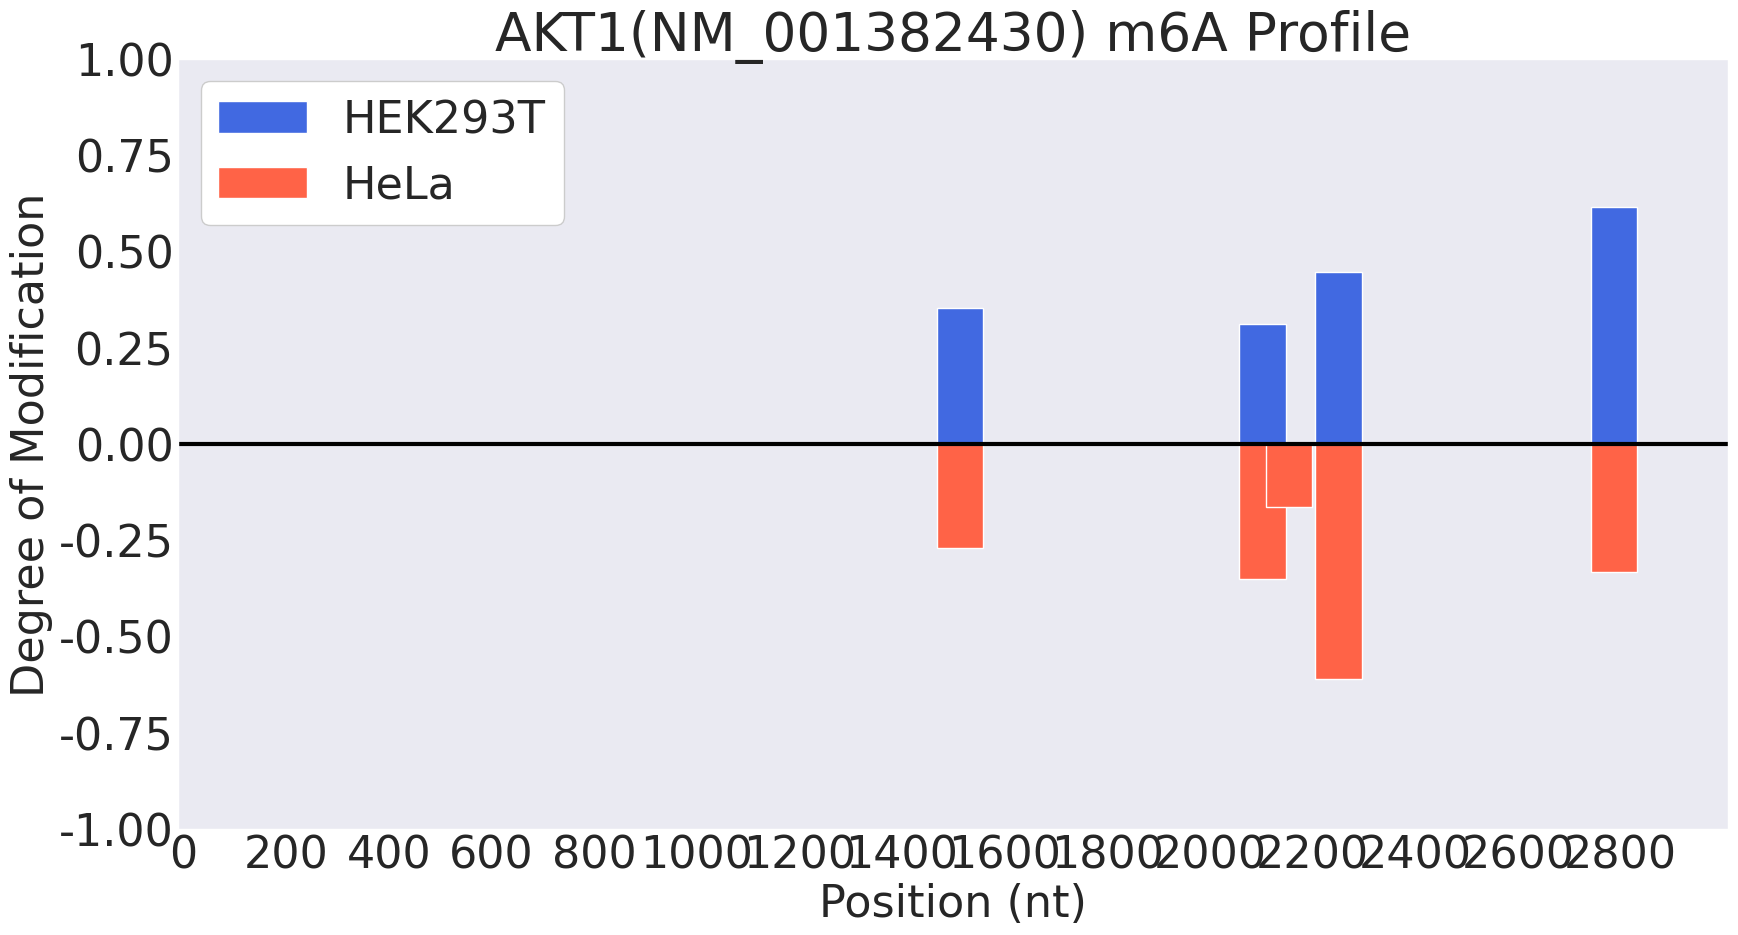

NM_001003681


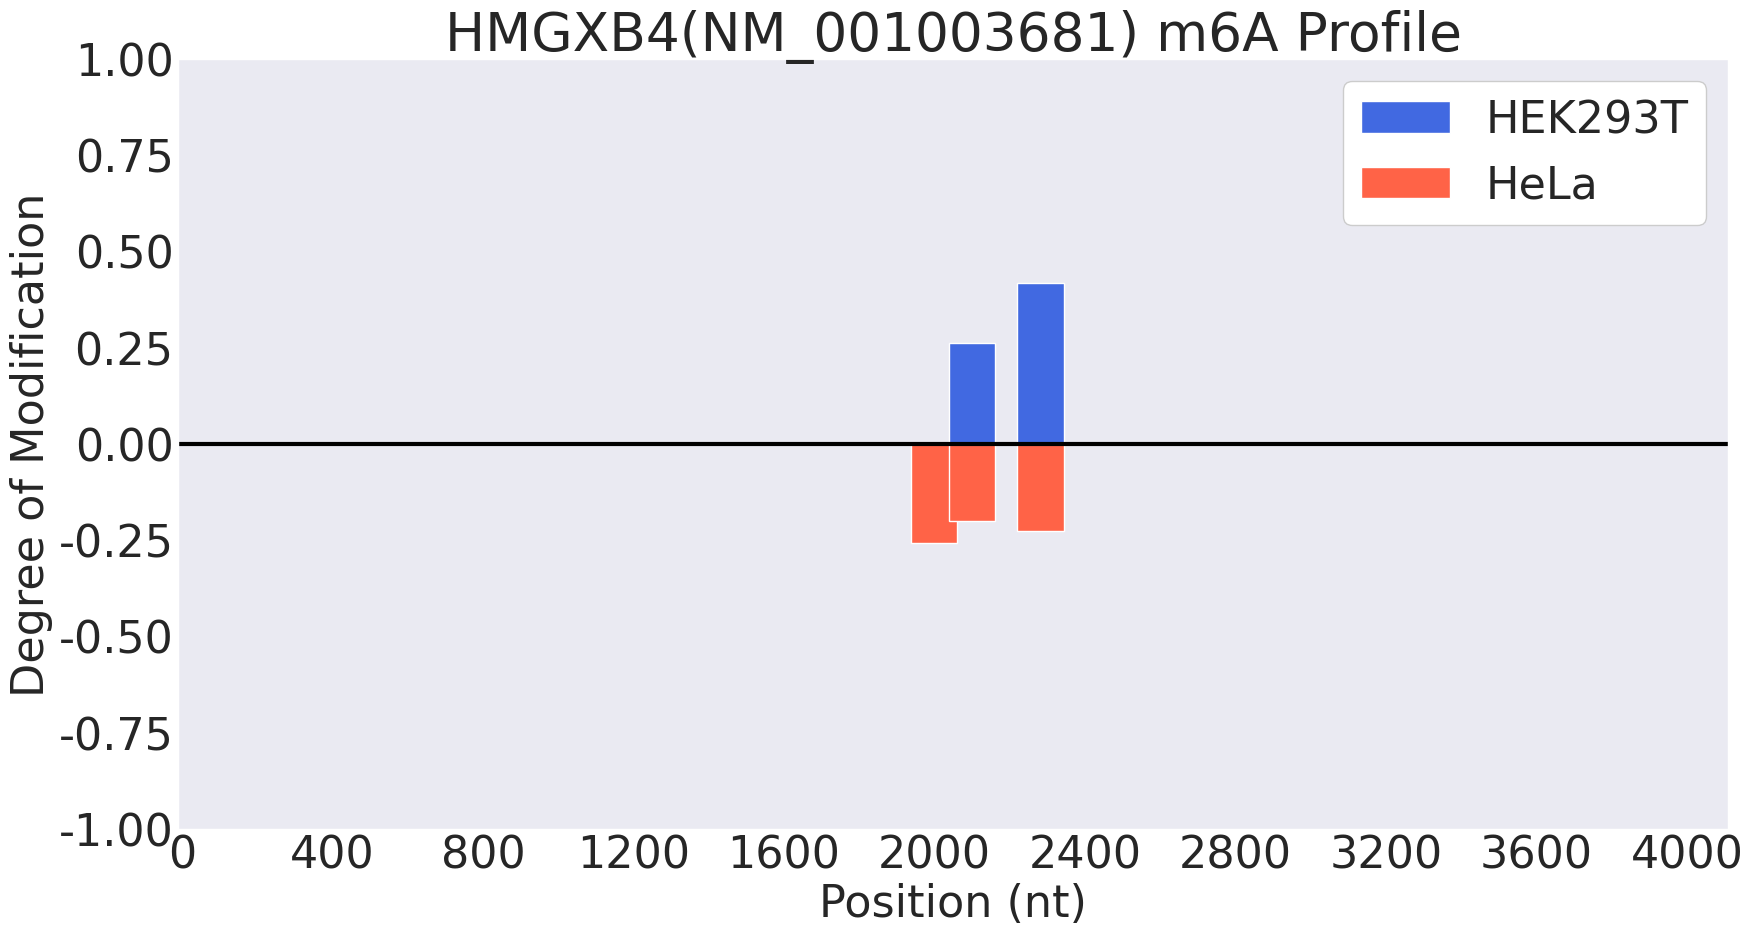

NM_018124


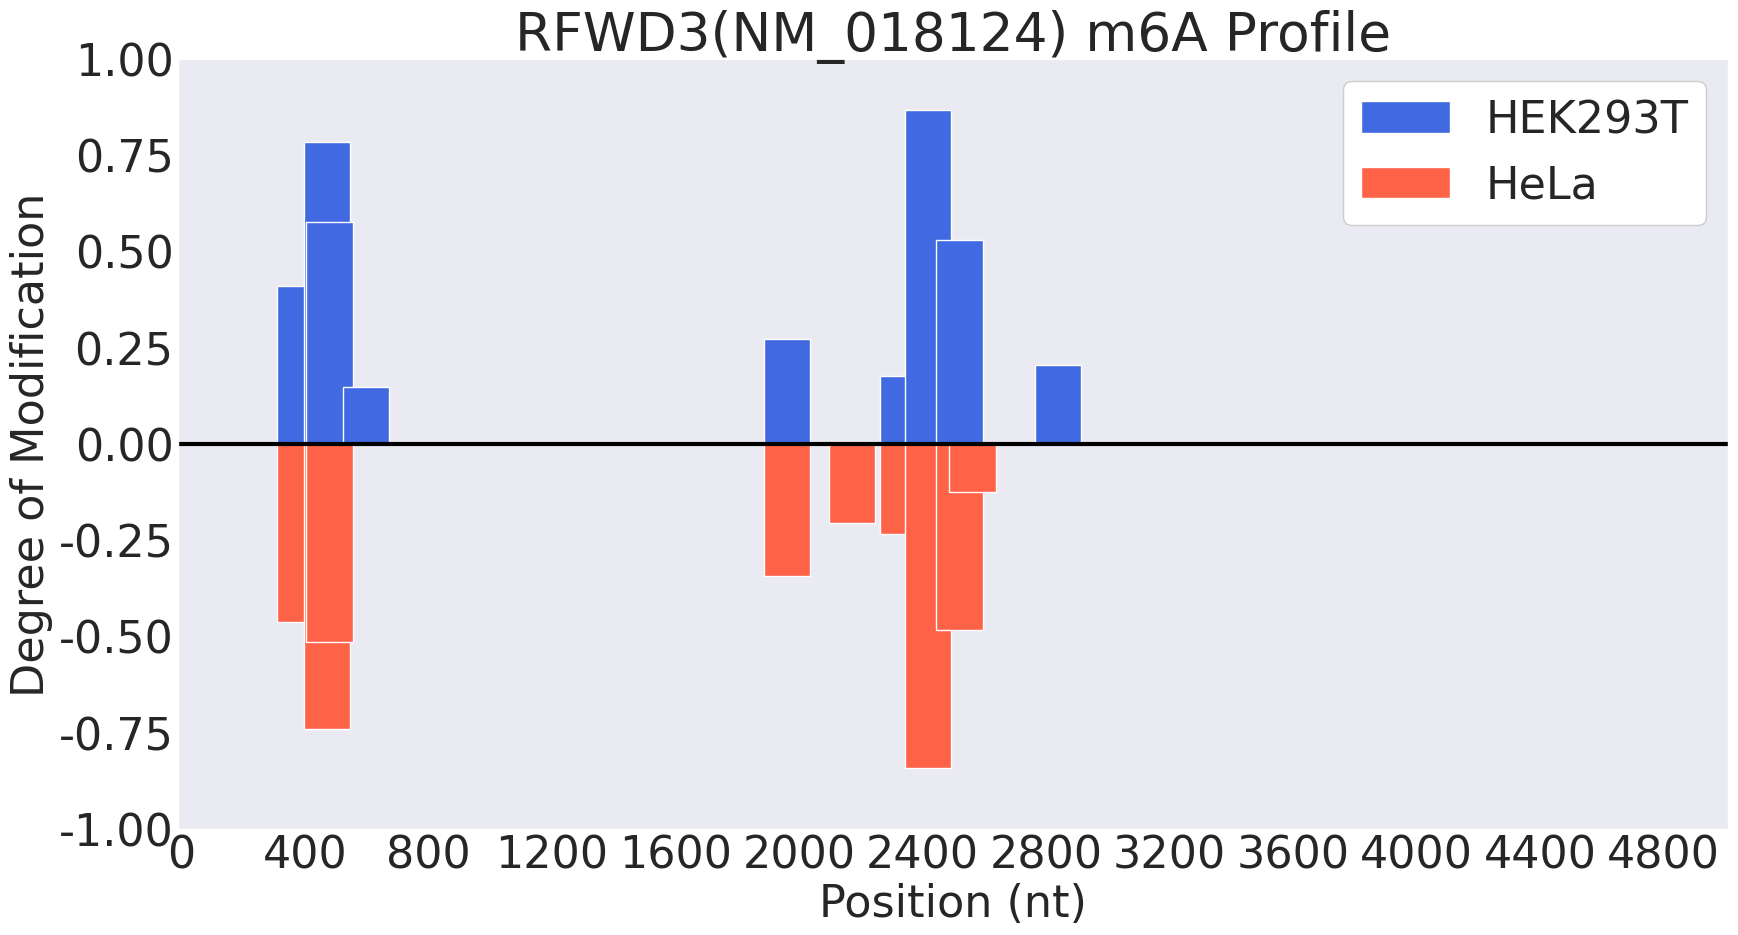

NM_001285878


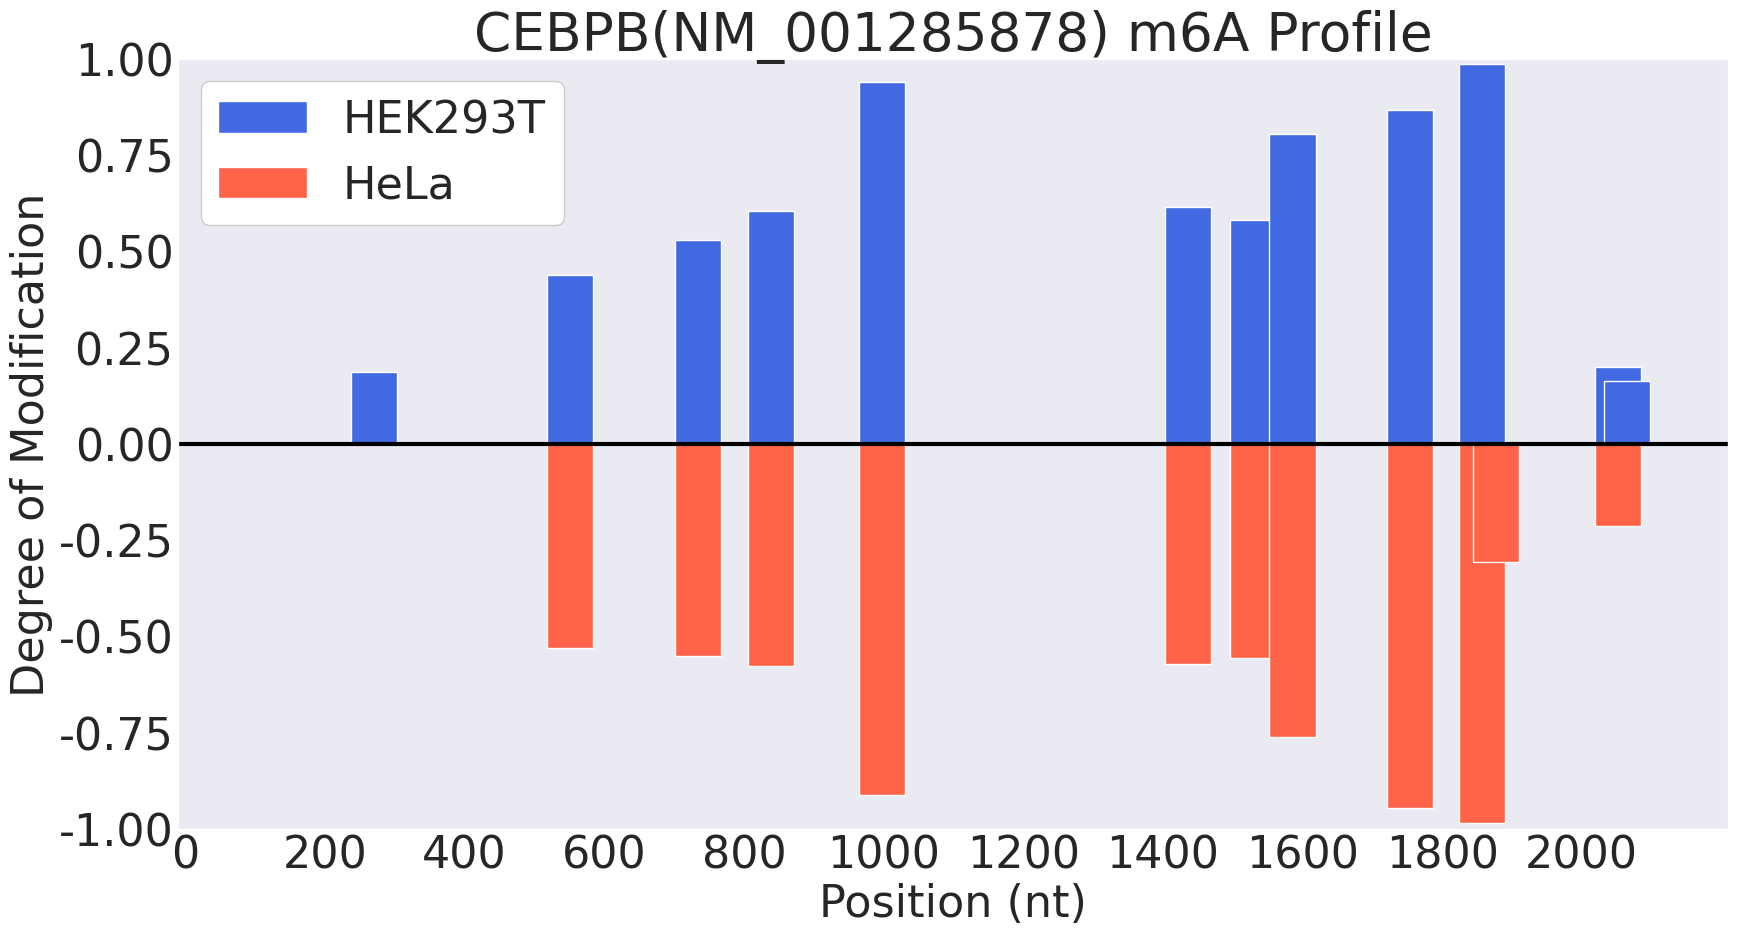

NM_001196


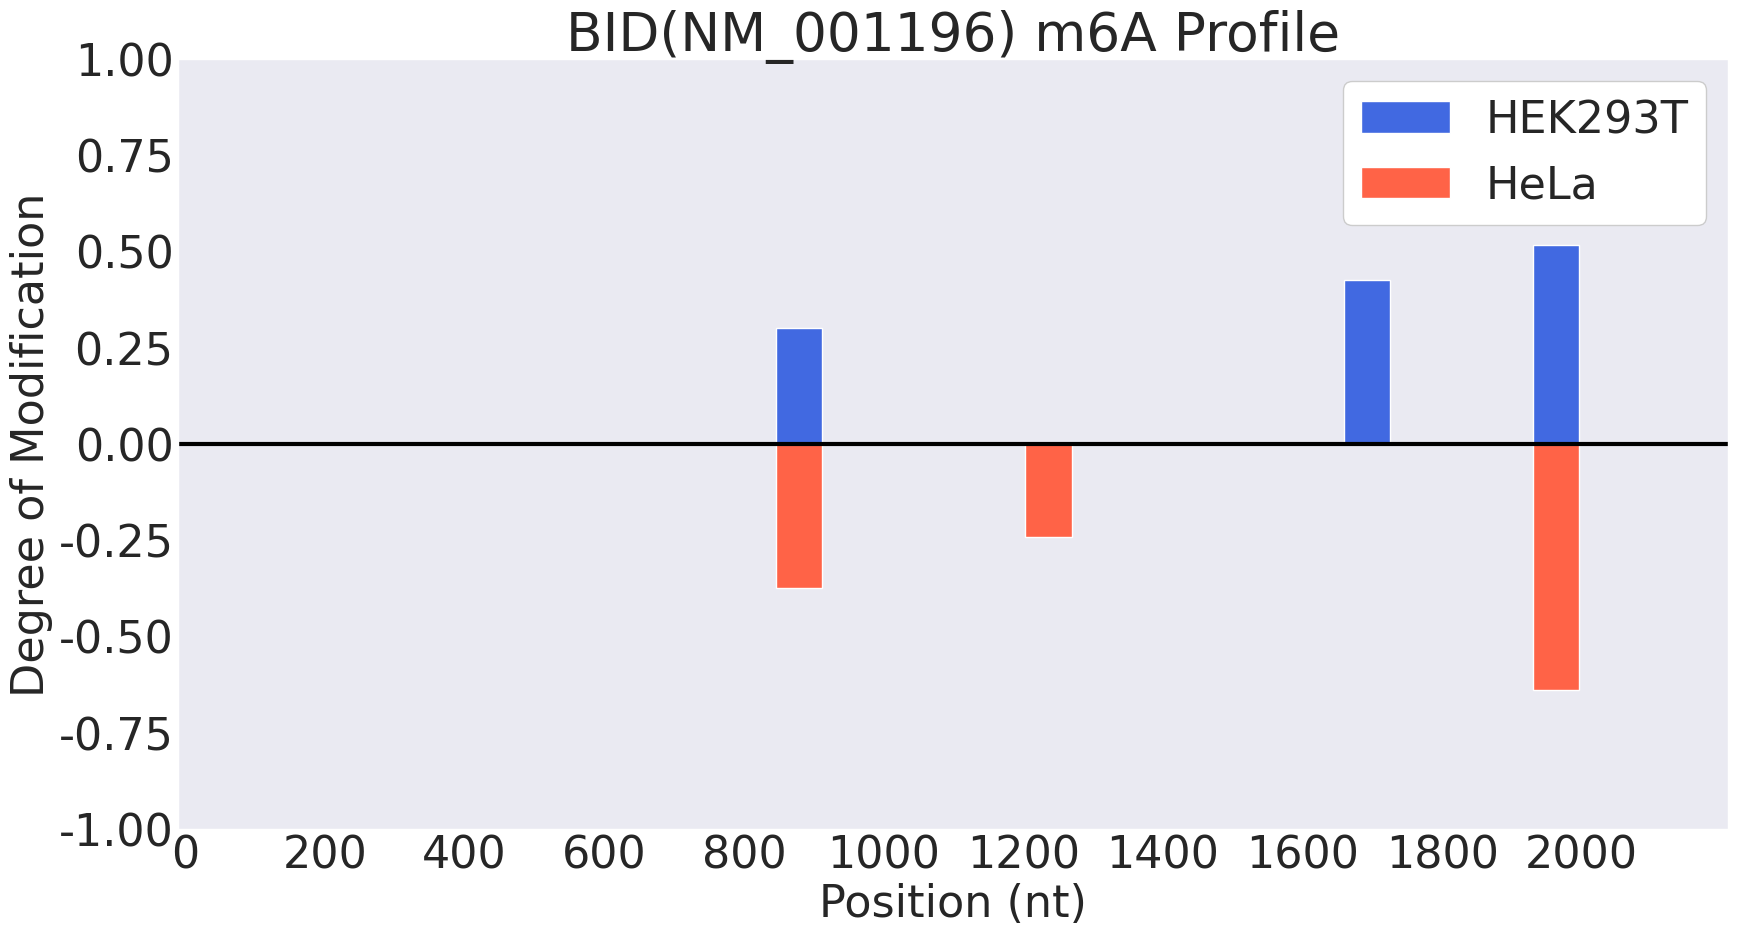

NM_022730


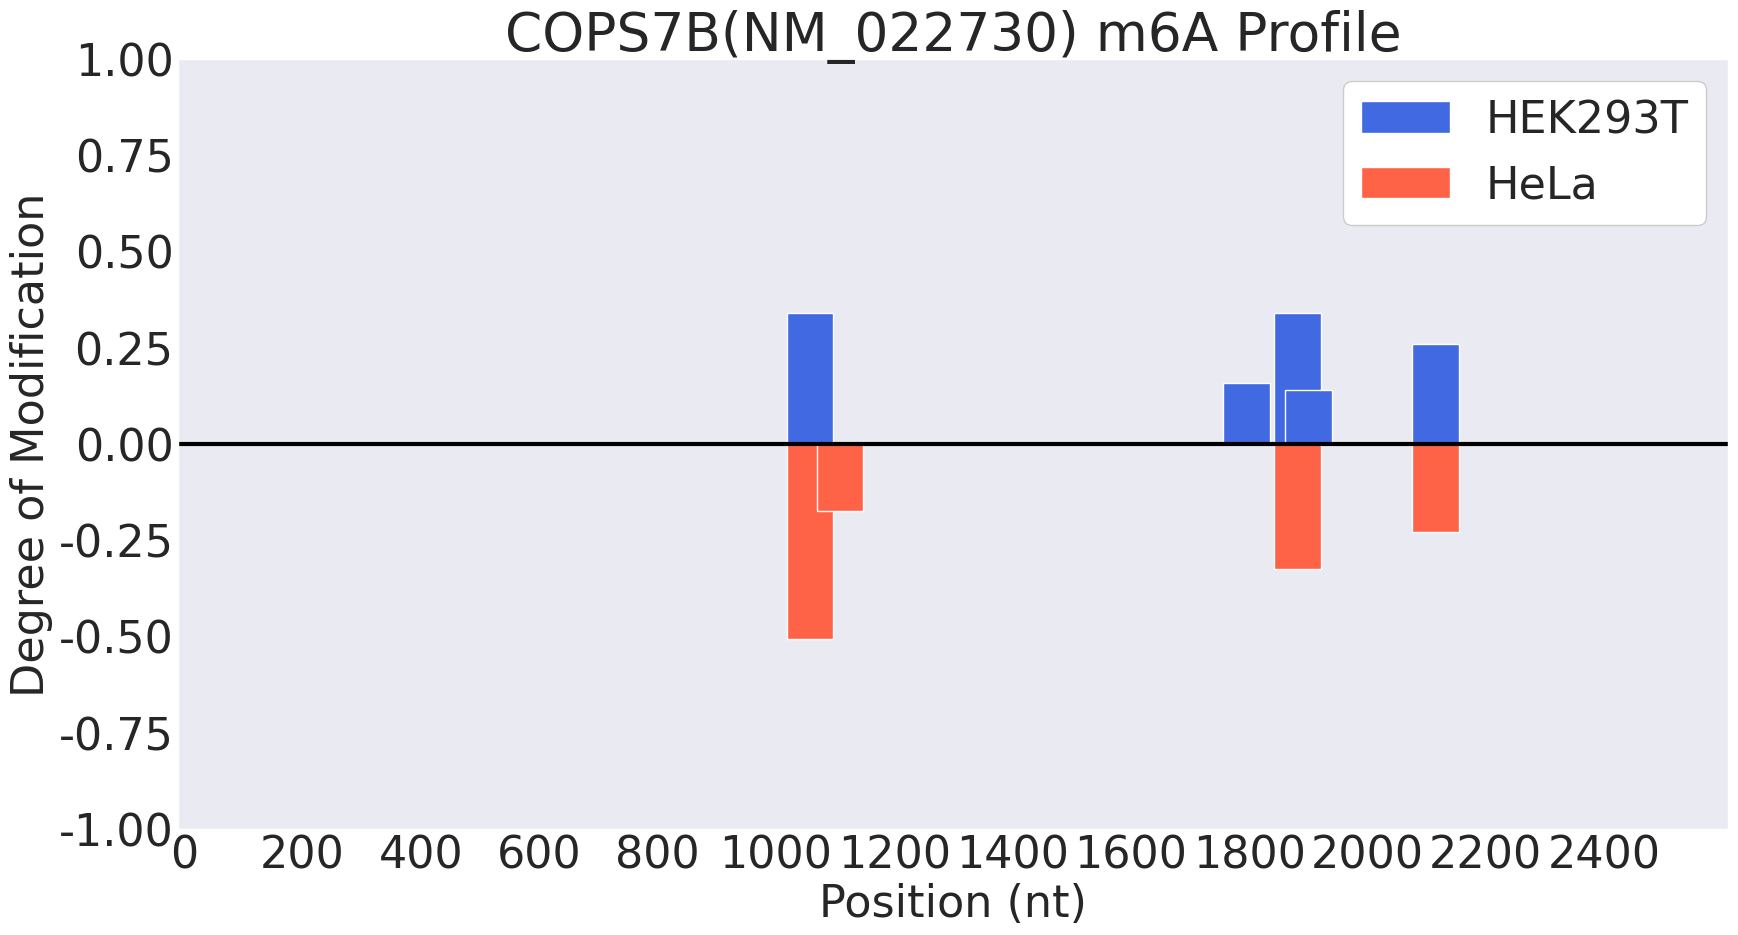

NM_001330511


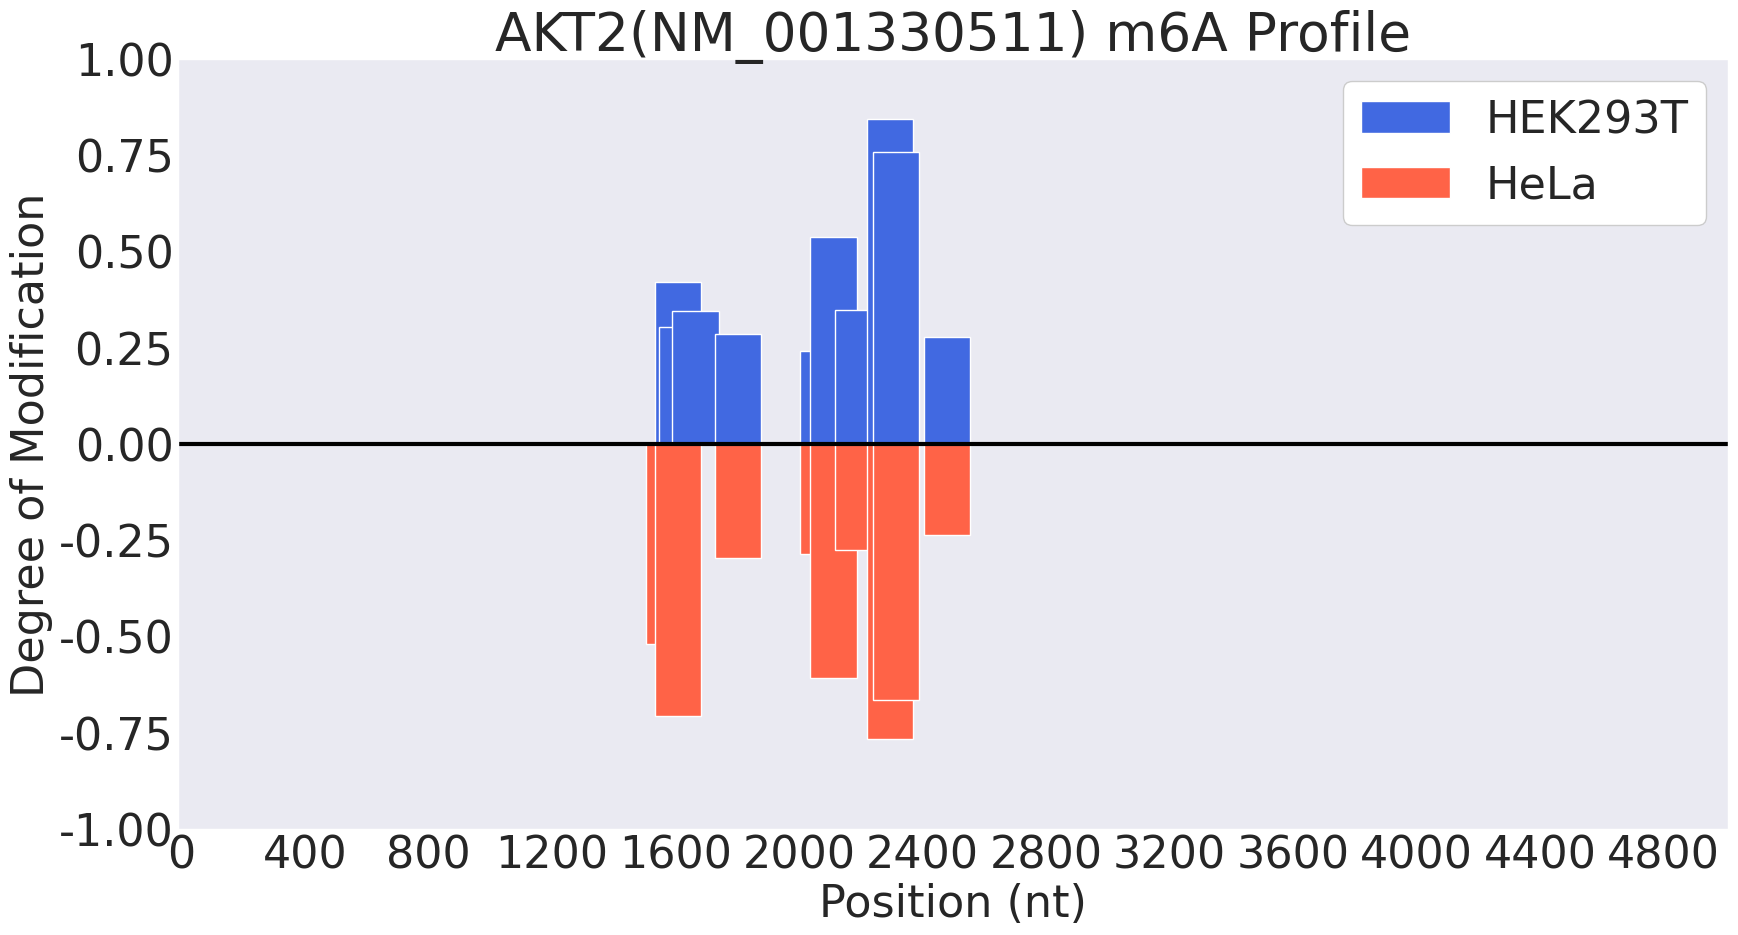

NM_014397


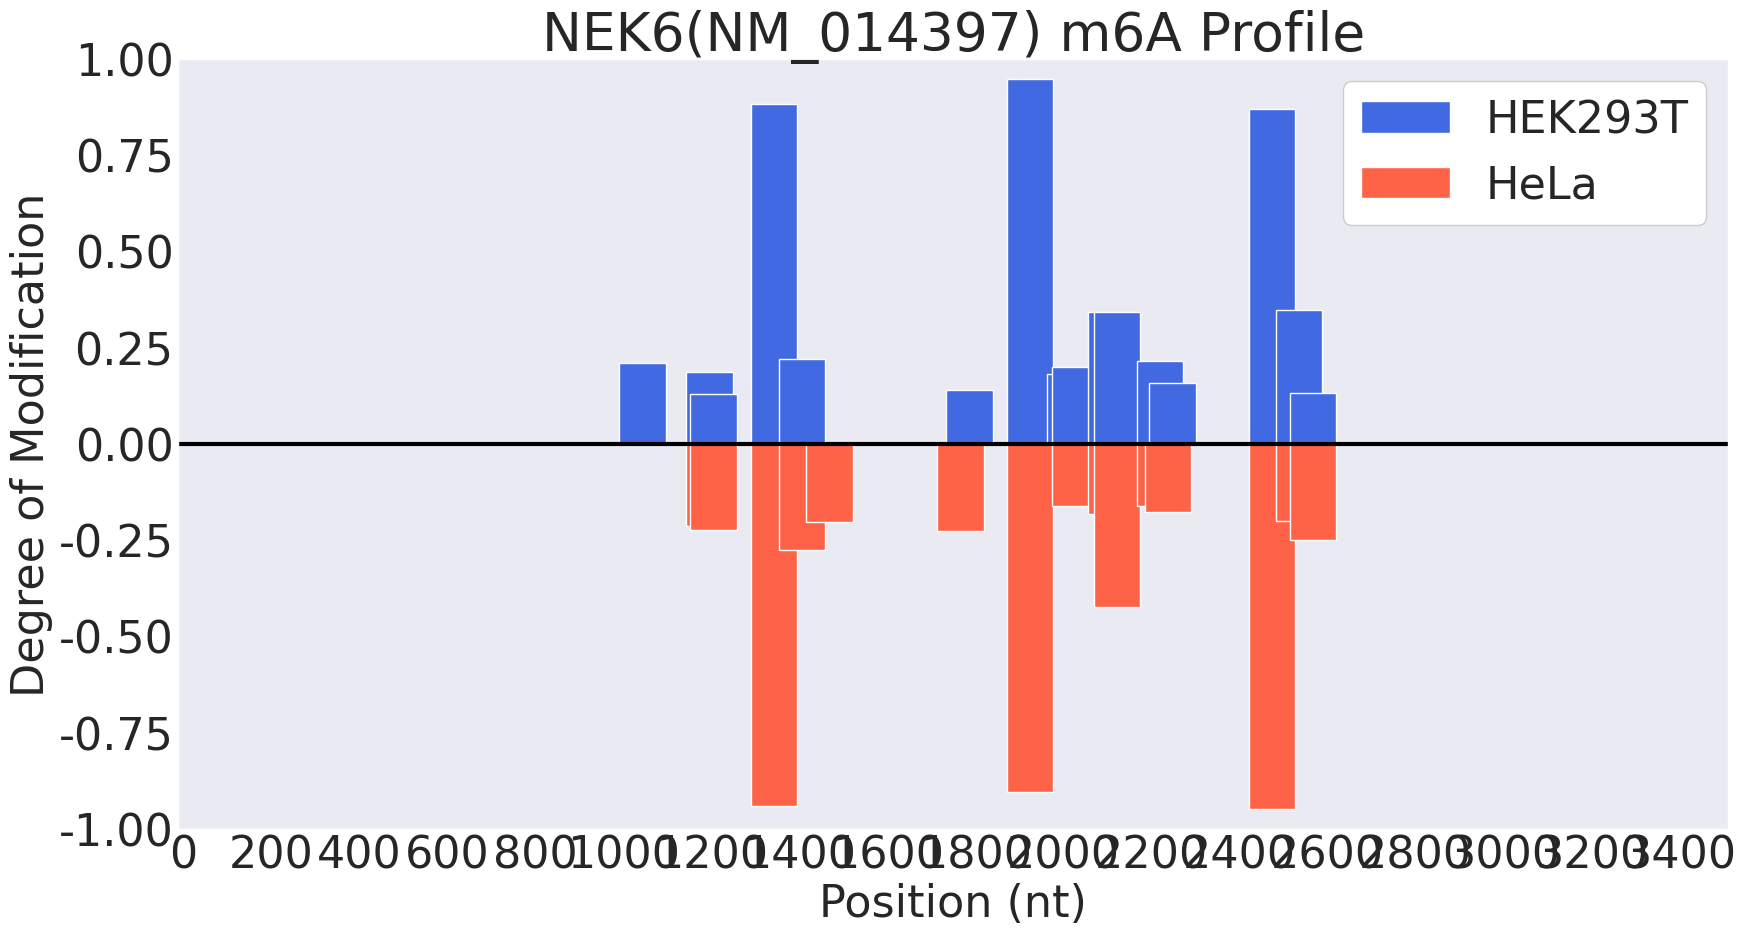

In [671]:
for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

In [ ]:
diff_df = diff_df.sort_values("l1", ascending=False)
select_df = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 3) & (diff_df["l1"] > 0.3)& (diff_df["refseq"].str.startswith("NM"))]
print(select_df)

In [ ]:
for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

In [606]:
diff_df = diff_df.sort_values("unique", ascending=False)
select_df = diff_df[(diff_df["unique"] >= 3)]
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
14491     NR_003287    0.324802      22.686725          3         4  0.166667   
15426     NR_145819    0.719899      11.873148          9         9  0.500000   
15427     NR_145822    0.522630      16.245400          4         5  0.285714   
15434     NR_146117    0.669787       9.884968          7         9  0.454545   
8078      NM_004289    0.000000       0.841579          0         8  0.000000   
3117   NM_001257370    0.879484       4.084269         31        31  0.675676   
15440     NR_146151    0.673324       1.215896          2         5  0.400000   

       unique        l1        l2  
14491       5  0.721812  0.642546  
15426       5  0.412946  0.332579  
15427       5  0.587802  0.487735  
15434       5  0.462540  0.396482  
8078        5  0.518009  0.320428  
3117        4  0.222983  0.084153  
15440       3  0.518225  0.430031  


In [ ]:
for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

In [572]:
diff_df = diff_df.sort_values("cross_entropy", ascending=False)
select_df = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 5) & (diff_df["cross_entropy"] > 10)]
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
9723      NM_014268    0.319285      17.270220          5         2  0.400000   
15427     NR_145822    0.522630      16.245400          4         5  0.285714   
7676      NM_003298    0.736994      15.317089          6         3  0.500000   
10692     NM_016614    0.737679      15.200104          5         3  0.600000   
12397     NM_031229    0.681589      15.146221          7         3  0.428571   
...             ...         ...            ...        ...       ...       ...   
3639   NM_001282884    0.857992      10.159616          7         4  0.571429   
12247     NM_025109    0.896958      10.135535          5         2  0.400000   
1271   NM_001102454    0.470869      10.082918          6         3  0.285714   
10084     NM_015099    0.724687      10.024654          6         2  0.333333   
10960     NM_017974    0.854185      10.015646          7         4  0.571429   

       unique  
9723       

In [ ]:
for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

In [530]:
hela_df[hela_df["refseq"] == "NM_198834"]["pos"].sort_values().values

array([  573,  1787,  1789, ...,  9993,  9999, 10001])

In [531]:
hek_df[hek_df["refseq"] == "NM_198834"]["pos"].sort_values().values

array([   24,    43,    53, ...,  9993,  9999, 10001])

In [527]:
print(hek_df_m6a_groupby.get_group("NM_198834"))

                label_id      p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
27707171   NM_198834:115  24.607346     -0.009072      -52.503963         16   
27707257   NM_198834:146  33.168144     -0.008857     -105.895348         29   
27707585   NM_198834:265  64.712570     -0.060439     -176.984528         62   
27707794   NM_198834:335  17.287405     -0.016219      -37.560730         13   
27708000   NM_198834:403  15.846976     -0.013326      -49.053020         15   
27708017   NM_198834:408  56.046185     -0.050796     -163.868347         55   
27709095  NM_198834:7751  21.012968     -0.017399      -51.188557         16   
27709149  NM_198834:7947  51.598404     -0.025002     -158.582581         49   
27709303  NM_198834:8446  20.250862     -0.014767      -36.876820         11   
27709528  NM_198834:9275  54.441692     -0.025651     -146.760361         45   
27709711  NM_198834:9934  62.195335     -0.052229     -185.615952         58   

          logsum_p_neg  logsum_1_p_neg 

In [532]:
print(hela_df_m6a_groupby.get_group("NM_198834"))

                label_id      p_sum  logsum_1_p_pos       dom  count_all  \
23861896  NM_198834:4368  21.869053      -36.048767  0.656250         36   
23862357  NM_198834:5907  24.628328      -32.520393  0.600000         44   
23862894  NM_198834:7751  17.333284      -40.716816  0.246154         68   
23862948  NM_198834:7947  47.275314     -150.134781  0.723077         66   
23863250  NM_198834:9023  13.646009      -36.455734  0.152941         86   
23863285  NM_198834:9144  20.523294      -54.184177  0.232558         88   
23863327  NM_198834:9275  55.096375     -174.421448  0.627907         88   
23863510  NM_198834:9934  71.941490     -243.217773  0.742268         97   

          count_dom  count_pos      pm6a     refseq   pos  
23861896         32         14  1.236890  NM_198834  4368  
23862357         40         12  0.955026  NM_198834  5907  
23862894         65         13  1.003827  NM_198834  7751  
23862948         65         46  2.726111  NM_198834  7947  
23863250       

In [534]:
hek_df[hek_df["label_id"] == "NM_198834:5907"]

,label_id,p_sum,logsum_p_pos,logsum_1_p_pos,count_pos,logsum_p_neg,logsum_1_p_neg,count_neg,logsum_p_all,logsum_1_p_all,count_all,dom,count_dom,pm6a,refseq,pos
27708558,NM_198834:5907,25.266584,-0.033863,-22.312515,10,-63.715866,-0.171679,27,-68.76915,-38.654781,59,0.462963,54,0.530454,NM_198834,5907


In [549]:
gene_list = [
    "NM_021135",
    "NM_001227",
    "NM_001458",
    "NM_145754",
    "NM_198838",
    "NM_198834",
    "NR_130139",
    "NM_001297555",
    "NM_032765",

]

In [ ]:
for gene in gene_list:
    plot(gene)

In [ ]:
plot("NM_001196")

In [ ]:
plot("NM_001227")

In [ ]:
plot("NM_145754")

In [623]:
old_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/biological/293t/agg_genome_v2/gene_df_final.pkl")

In [624]:
print(old_df)

                       genome_id gene_symbol  pred_dom  pred_pm6a  drach  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4       0.0   0.017590  False   
chr10:+:1000683  chr10:+:1000683      GTPBP4       0.0   0.017638   True   
chr10:+:1000685  chr10:+:1000685      GTPBP4       0.0   0.020265  False   
chr10:+:1000694  chr10:+:1000694      GTPBP4       0.0   0.004724  False   
chr10:+:1000701  chr10:+:1000701      GTPBP4       0.0   0.013277   True   
...                          ...         ...       ...        ...    ...   
chrX:-:9760777    chrX:-:9760777      GPR143       0.0   0.024428   True   
chrX:-:9760786    chrX:-:9760786      GPR143       0.0   0.000753  False   
chrX:-:9760787    chrX:-:9760787      GPR143       0.0   0.001612  False   
chrX:-:9760788    chrX:-:9760788      GPR143       0.0   0.005260  False   
chrX:-:9760817    chrX:-:9760817      GPR143       0.0   0.001145  False   

           

In [631]:
new_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.genomic.npz"
with np.load(new_df, allow_pickle=True) as data:
    new_df = pd.DataFrame({key: data[key] for key in data.keys()})
new_df["pm6a"] = calc_pm6a(new_df)
print(new_df)

                genome_id gene_symbol  coding       dom  count_dom  \
0         chr10:+:1000681      GTPBP4    True  0.008403        476   
1         chr10:+:1000683      GTPBP4    True  0.014463        484   
2         chr10:+:1000685      GTPBP4    True  0.023404        470   
3         chr10:+:1000694      GTPBP4    True  0.014286        490   
4         chr10:+:1000701      GTPBP4    True  0.012474        481   
...                   ...         ...     ...       ...        ...   
13228010   chrX:-:9760794      GPR143    True  0.000000          5   
13228011   chrX:-:9760797      GPR143    True  0.000000          5   
13228012   chrX:-:9760808      GPR143    True  0.000000          5   
13228013   chrX:-:9760817      GPR143    True  0.000000          5   
13228014   chrX:-:9760823      GPR143    True  0.000000          4   

          logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  
0              -2.268124          1        482         1  0.009328  
1               0.000

In [626]:
print(old_df["gene_symbol"].nunique())

11646


In [632]:
print(new_df["gene_symbol"].nunique())

15642


In [637]:
new_df["modified"] = new_df["pm6a"] > threshold
print(new_df[new_df["modified"] & (new_df["count_dom"] >= 20)])

                  genome_id gene_symbol  coding       dom  count_dom  \
1301      chr10:+:100364512         SCD    True  0.359959       2942   
1314      chr10:+:100364569         SCD    True  0.218364       2995   
1518      chr10:+:100381333    OLMALINC   False  0.155556        135   
1602      chr10:+:100388236    OLMALINC   False  0.180000        100   
1613      chr10:+:100388266    OLMALINC   False  0.339450        109   
...                     ...         ...     ...       ...        ...   
13226835    chrX:-:85864587         CHM    True  0.500000         26   
13226843    chrX:-:85864614         CHM    True  0.142857         28   
13226869    chrX:-:85864679         CHM    True  0.576923         26   
13227203    chrX:-:85956342         CHM    True  0.200000         20   
13227545    chrX:-:85971260         CHM    True  0.481481         27   

          logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  modified  
1301        -3305.878662        910       3040         1

In [634]:
print(threshold)

0.712


In [639]:
new_m6a_df = new_df[new_df["modified"] & (new_df["count_dom"] >= 20)]

count_coding_drach = new_m6a_df.groupby(["coding"]).size()

In [640]:
print(count_coding_drach)

coding
False     5834
True     99790
dtype: int64


NM_198834


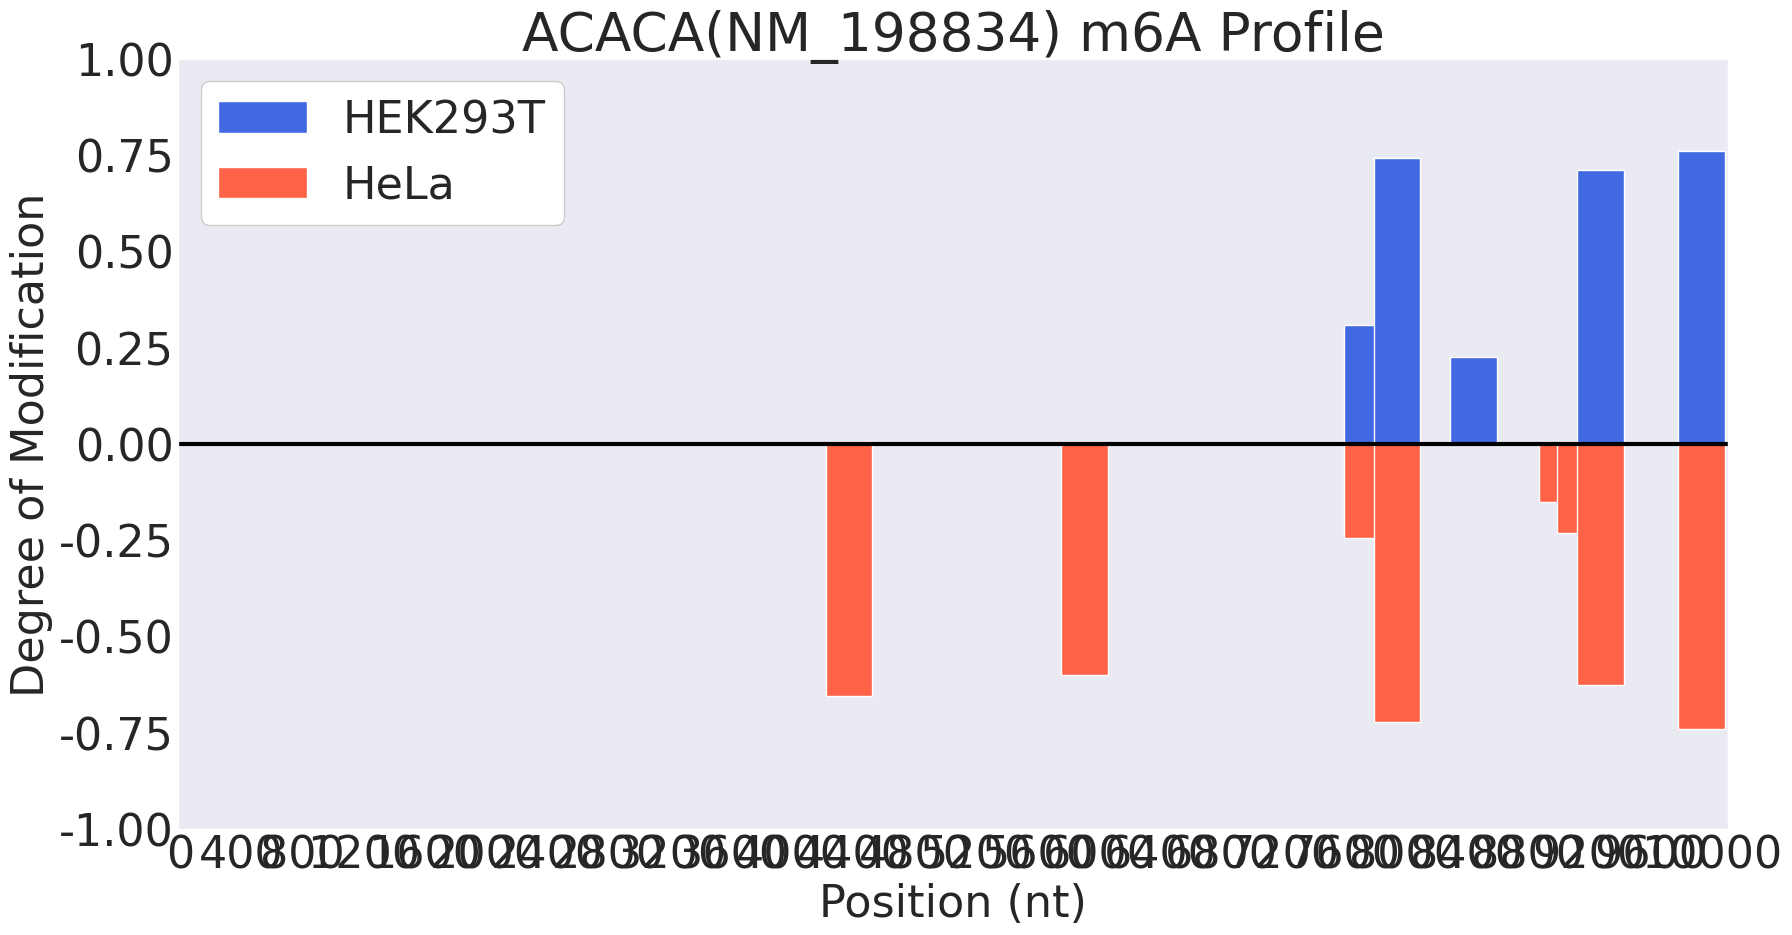

In [658]:
plot("NM_198834")